#  Notebook 1 — EDA & Limpieza
## HMDA New York 2024: Sesgo, Equidad y Explicabilidad en Hipotecas

**Autores:** Izan Cuesta Corbí · Dennis García Solera · Marcos Segurado Llopis · Jesús Cano Moya  
**Dataset:** Home Mortgage Disclosure Act (HMDA) — New York 2024 (CFPB)

---
> **Objetivo de este notebook:** Exploración profunda del dataset, detección de sesgos en atributos sensibles (raza, sexo, etnia y edad), limpieza y preparación de los datos para los modelos posteriores.

> `RANDOM_STATE = 42` fijado globalmente para reproducibilidad.

--- 

### Imports

In [2]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

np.random.seed(42)
RANDOM_STATE = 42

In [3]:
os.makedirs('../outputs/images', exist_ok=True)

# Estilos globales para todos los gráficos
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style='whitegrid', palette='muted')

---
---

## Dataset

El dataset HMDA (Home Mortgage Disclosure Act) es publicado anualmente por la CFPB (Consumer Financial Protection Bureau) de EEUU. Contiene todas las solicitudes de hipoteca registradas en Nueva York durante 2024, incluyendo datos demográficos del solicitante, características del préstamo y la decisión final de la entidad financiera.

In [4]:
df_original = pd.read_csv('../data/state_NY.csv', low_memory=False)

print(f"\nPrimeras 5 filas:")
df_original.head(5)


Primeras 5 filas:


,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,549300WEZMN6QE5IIH42,35614,NY,36061.0,3.606102e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,9383,38.70,101900,253,1252,253,0
1,2024,549300WEZMN6QE5IIH42,10580,NY,36083.0,3.608304e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,1731,31.95,117800,64,234,773,0
2,2024,549300WEZMN6QE5IIH42,35614,NY,36061.0,3.606101e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4481,27.92,101900,257,109,40,63
3,2024,549300WEZMN6QE5IIH42,35004,NY,36103.0,3.610311e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3482,22.09,156200,68,1205,1498,16
4,2024,549300WEZMN6QE5IIH42,35614,NY,36119.0,3.611901e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2031,78.58,101900,130,254,90,54


---
### Exploración Inicial

In [5]:
def exploracion_inicial(df):
    print("=" * 55)
    print("  SHAPE")
    print("=" * 55)
    print(f"  Filas:    {df.shape[0]:,}")
    print(f"  Columnas: {df.shape[1]}")


    print("\n" + "=" * 55)
    print("  TIPOS DE DATOS")
    print("=" * 55)
    print(df.dtypes.to_string())


    print("\n" + "=" * 55)
    print("  VALORES FALTANTES (columnas con >0 nulos)")
    print("=" * 55)

    faltantes = df.isnull().sum()
    faltantes_df = pd.DataFrame({
        'N faltantes': faltantes, 
        '% faltantes': round(faltantes / len(df) * 100, 2)
    })
    faltantes_df = faltantes_df[faltantes_df['N faltantes'] > 0].sort_values('% faltantes', ascending=False)

    print(faltantes_df.to_string())
    print(f"\n  Total columnas con faltantes: {len(faltantes_df)}")
    print(f"  Total columnas sin faltantes: {df.shape[1] - len(faltantes_df)}")


In [6]:
exploracion_inicial(df_original)

  SHAPE
  Filas:    383,577
  Columnas: 99

  TIPOS DE DATOS
activity_year                                 int64
lei                                          object
derived_msa-md                                int64
state_code                                   object
county_code                                 float64
census_tract                                float64
conforming_loan_limit                        object
derived_loan_product_type                    object
derived_dwelling_category                    object
derived_ethnicity                            object
derived_race                                 object
derived_sex                                  object
action_taken                                  int64
purchaser_type                                int64
preapproval                                   int64
loan_type                                     int64
loan_purpose                                  int64
lien_status                                   int64
rev

In [7]:
print("=" * 55)
print(f"  VALORES DEL TARGET (action_taken)")
print("=" * 55)

actions = {
    1: 'Loan originated',
    2: 'Application approved but not accepted',
    3: 'Application denied',
    4: 'Application withdrawn by applicant',
    5: 'File closed for incompleteness',
    6: 'Purchased loan',
    7: 'Preapproval request denied',
    8: 'Preapproval request approved but not accepted'
}

conteo = df_original['action_taken'].value_counts(dropna=False)
target_df = pd.DataFrame({
    '': [actions[valor] for valor in conteo.index],
    'Valor': conteo.index,
    'Conteo': conteo.values
})
print(target_df.to_string(index=False))

  VALORES DEL TARGET (action_taken)
                                               Valor  Conteo
                              Loan originated      1  208787
                           Application denied      3   74545
           Application withdrawn by applicant      4   42225
                               Purchased loan      6   28198
               File closed for incompleteness      5   18373
        Application approved but not accepted      2    9897
Preapproval request approved but not accepted      8    1271
                   Preapproval request denied      7     281


**Observaciones**

- El dataset contiene **383.577 solicitudes de hipoteca** en Nueva York durante 2024,
  con 99 columnas que cubren características del préstamo, del solicitante y datos demográficos.

- El target `action_taken` tiene 8 valores posibles. Para nuestro problema de
  clasificación binaria nos quedamos únicamente con:
  - `1` → Préstamo concedido (**clase positiva**)
  - `3` → Solicitud denegada (**clase negativa**)
  
  Los valores restantes (préstamos comprados, solicitudes retiradas, ficheros incompletos, etc.)
  quedan excluidos porque no representan una decisión activa del banco sobre un solicitante
  concreto, lo cual introduciría ruido en el análisis de sesgo y equidad.

- Las columnas `derived_race`, `derived_sex` y `derived_ethnicity` son **atributos sensibles
  explícitos**. A diferencia de otros datasets donde el sesgo está codificado de forma indirecta, aquí
  disponemos de estas variables directamente para auditoría de equidad (*fairness*).

---
### Preparación y Filtrado Base

#### Mapeado para clasificación binaria

In [8]:
df_base = df_original[df_original['action_taken'].isin([1, 3])].copy()

# Recodificar target: 1 = concedido, 0 = denegado
df_base['action_taken'] = df_base['action_taken'].map({1: 1, 3: 0})
df_base.to_csv('../data/hmda_base.csv', index=False)

In [9]:
exploracion_inicial(df_base)

  SHAPE
  Filas:    283,332
  Columnas: 99

  TIPOS DE DATOS
activity_year                                 int64
lei                                          object
derived_msa-md                                int64
state_code                                   object
county_code                                 float64
census_tract                                float64
conforming_loan_limit                        object
derived_loan_product_type                    object
derived_dwelling_category                    object
derived_ethnicity                            object
derived_race                                 object
derived_sex                                  object
action_taken                                  int64
purchaser_type                                int64
preapproval                                   int64
loan_type                                     int64
loan_purpose                                  int64
lien_status                                   int64
rev

**Observaciones**

- El dataset base (solo acciones 1 y 3) contiene **~283.000 instancias** y **99 columnas**.

- **Tipos de datos:** Hay una mezcla de `float64`, `int64` y `object`. Hay que tener en cuenta que muchas columnas que
  parecen numéricas (e.g. `applicant_race-1`, `denial_reason-1`) ya han sido codificadas como
  enteros con valores especiales (código 6 = "No disponible", código 7 = "No aplica"). Por ello, no será necesario volver a codificarlas en nuestro preprocesamiento.

---
---

## EDA

---
### Estadística Descriptiva

El primer paso es entender la magnitud y dispersión de nuestras variables numéricas en crudo. 

*   **count:** Nos permite ver de un vistazo qué columnas numéricas tienen graves problemas de valores faltantes (si el count es mucho menor al total de filas).
*   **mean vs 50% (mediana):** Si la media es mucho mayor que la mediana, nos indicará un sesgo a la derecha.
*   **max:** Nos ayudará a identificar posibles errores de entrada o préstamos excepcionalmente altos antes de limpiar.

In [10]:
# Variables Numéricas Financieras
caracteristicas_num_f = [
    'loan_amount', 'income', 'property_value', 'loan_to_value_ratio'
]

# Nos aseguramos de que sean numéricas
for columna in caracteristicas_num_f:
    df_base[columna] = pd.to_numeric(df_base[columna], errors='coerce')

print("Estadística Descriptiva de Variables Financieras (Datos Crudos):")
display(df_base[caracteristicas_num_f].describe().round(2))

# Variables Numéricas Censales
caracteristicas_num_c = [
    'tract_population', 'tract_minority_population_percent', 'ffiec_msa_md_median_family_income',
    'tract_to_msa_income_percentage', 'tract_median_age_of_housing_units'
]

# Nos aseguramos de que sean numéricas
for columna in caracteristicas_num_c:
    df_base[columna] = pd.to_numeric(df_base[columna], errors='coerce')

print("Estadística Descriptiva de Variables Censales (Datos Crudos):")
display(df_base[caracteristicas_num_c].describe().round(2))

Estadística Descriptiva de Variables Financieras (Datos Crudos):


,loan_amount,income,property_value,loan_to_value_ratio
count,2.833320e+05,2.635580e+05,2.702520e+05,265913.00
mean,4.151033e+05,5.669200e+02,8.129197e+05,81.95
std,3.870115e+06,1.947893e+05,7.689853e+06,4125.97
min,5.000000e+03,-1.122900e+04,5.000000e+03,0.00
25%,1.050000e+05,7.500000e+01,2.550000e+05,55.36
50%,2.050000e+05,1.210000e+02,4.950000e+05,75.00
75%,4.350000e+05,1.900000e+02,7.750000e+05,84.55
max,6.008550e+08,1.000000e+08,1.400005e+09,2000000.00


Estadística Descriptiva de Variables Censales (Datos Crudos):


,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_median_age_of_housing_units
count,283332.00,283332.00,283332.00,283332.00,283332.00
mean,4302.85,33.93,110956.23,111.63,45.61
std,1632.54,27.32,25522.14,47.42,23.33
min,0.00,0.00,0.00,0.00,0.00
25%,3127.00,12.93,96900.00,85.00,37.00
50%,4211.00,24.07,101900.00,105.00,51.00
75%,5363.00,45.57,117800.00,128.00,63.00
max,13385.00,100.00,156200.00,296.00,80.00


**Interpretación de la Estadística Descriptiva:**

* **Valores faltantes:** Al observar la fila `count`, notamos de inmediato que las columnas no tienen la misma cantidad de datos. Mientras que el monto del préstamo y todas las variables censales están completas (~283k registros), columnas financieras críticas como los ingresos (`income` cae a ~263k) y el valor de la propiedad (`property_value` cae a ~270k) presentan huecos. Esto confirma la necesidad de aplicar técnicas de manejo de valores faltantes antes de modelar.

* **Fuerte sesgo a la derecha:** En las variables de capital (`loan_amount` y `property_value`), la media es prácticamente el doble que la mediana (percentil 50%). Por ejemplo, la hipoteca mediana (`loan_amount`) es de 205.000$, pero la media se dispara a más de 415.000$. Esto nos confirma que las distribuciones financieras no son normales y están fuertemente estiradas hacia la derecha por valores altísimos.

* **Valores atípicos y anomalías:**
    * **El "extremo" de Nueva York:** Los valores máximos son astronómicos (préstamos de 600 millones y propiedades de 1.400 millones de dólares), reflejando el mercado inmobiliario comercial y lujoso del estado.
    * **Ratio LTV irreal:** La variable `loan_to_value_ratio` tiene una mediana perfecta del 75% (lo estándar en hipotecas), pero su valor máximo alcanza el 2.000.000. A diferencia de las propiedades de lujo, esto es claramente un error de captura en la base de datos del banco, no una realidad del mercado.
    * **Ingresos:** La variable `income` presenta un valor mínimo negativo (-11.229). En un contexto financiero, esto puede representar a solicitantes (como autónomos o empresarios) que reportaron pérdidas netas ese año.


* **El Contexto Sociodemográfico (Variables Censales):** A diferencia de las financieras, los datos del censo son extremadamente robustos (sin nulos). Destaca la gran segregación demográfica en las zonas de Nueva York: el porcentaje de minorías (`tract_minority_population_percent`) oscila desde el 0% hasta el 100% dependiendo del barrio, con una media del 33.9%. Estas variables serán nuestro núcleo duro más adelante para investigar posibles sesgos.

Además, inspeccionaremos los valores únicos de los atributos "sensibles al sesgo" para confirmar que coinciden con la codificación oficial HMDA.

In [11]:
print("=" * 50)
print("Conteo de valores únicos en Variables Sensibles")
print("=" * 50)
print()
print(df_base['derived_race'].value_counts(dropna=False).to_string())
print()
print(df_base['derived_sex'].value_counts(dropna=False).to_string())
print()
print(df_base['derived_ethnicity'].value_counts(dropna=False).to_string())

Conteo de valores únicos en Variables Sensibles

derived_race
White                                        179191
Race Not Available                            48664
Asian                                         25547
Black or African American                     22379
Joint                                          4915
American Indian or Alaska Native               1194
2 or more minority races                        711
Native Hawaiian or Other Pacific Islander       606
Free Form Text Only                             125

derived_sex
Male                 99230
Joint                92270
Female               66940
Sex Not Available    24892

derived_ethnicity
Not Hispanic or Latino     207839
Ethnicity Not Available     44718
Hispanic or Latino          24464
Joint                        6138
Free Form Text Only           173


---
### Desbalance de Clases y Sesgo Demográfico

Como parte vital del Criterio 2 de nuestra rúbrica, evaluamos problemas inherentes al dataset. En primer lugar, analizaremos la proprocionalidad entre casos "aprobados" y "denegados".


Aún así, lo que realmente importa en este trabajo específico es si hay mayor o menor probabilidad de ser aprobado en función del grupo demográfico al que pertenece el solicitante.

Para ello, calculamos la tasa de aprobación media (`action_taken = 1`) por grupo en cada variable
sensible. Una diferencia estadísticamente significativa entre grupos constituye *disparate impact*,
regulado bajo el Fair Housing Act estadounidense.

#### Distribución de clases

action_taken
1    0.736899
0    0.263101
Name: proportion, dtype: float64


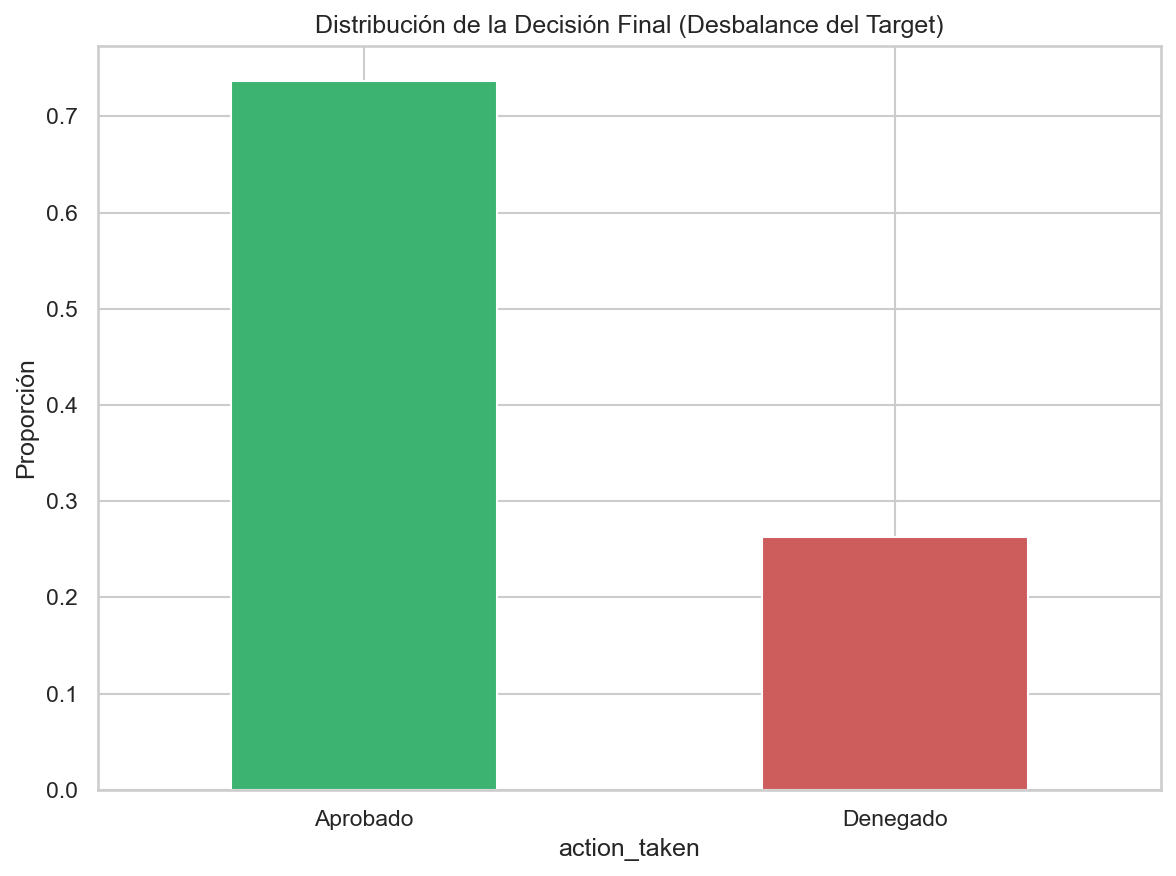

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

print(df_base['action_taken'].value_counts(normalize=True))

df_base['action_taken'].value_counts(normalize=True).plot(kind='bar', ax=ax, color=['mediumseagreen', 'indianred'])
ax.set_title('Distribución de la Decisión Final (Desbalance del Target)')
ax.set_ylabel('Proporción')
ax.set_xticklabels(['Aprobado', 'Denegado'], rotation=0)

plt.tight_layout()
plt.savefig('../outputs/images/2_1_desbalance.png', dpi=300, bbox_inches='tight')
plt.show()

#### Sesgo demográfico

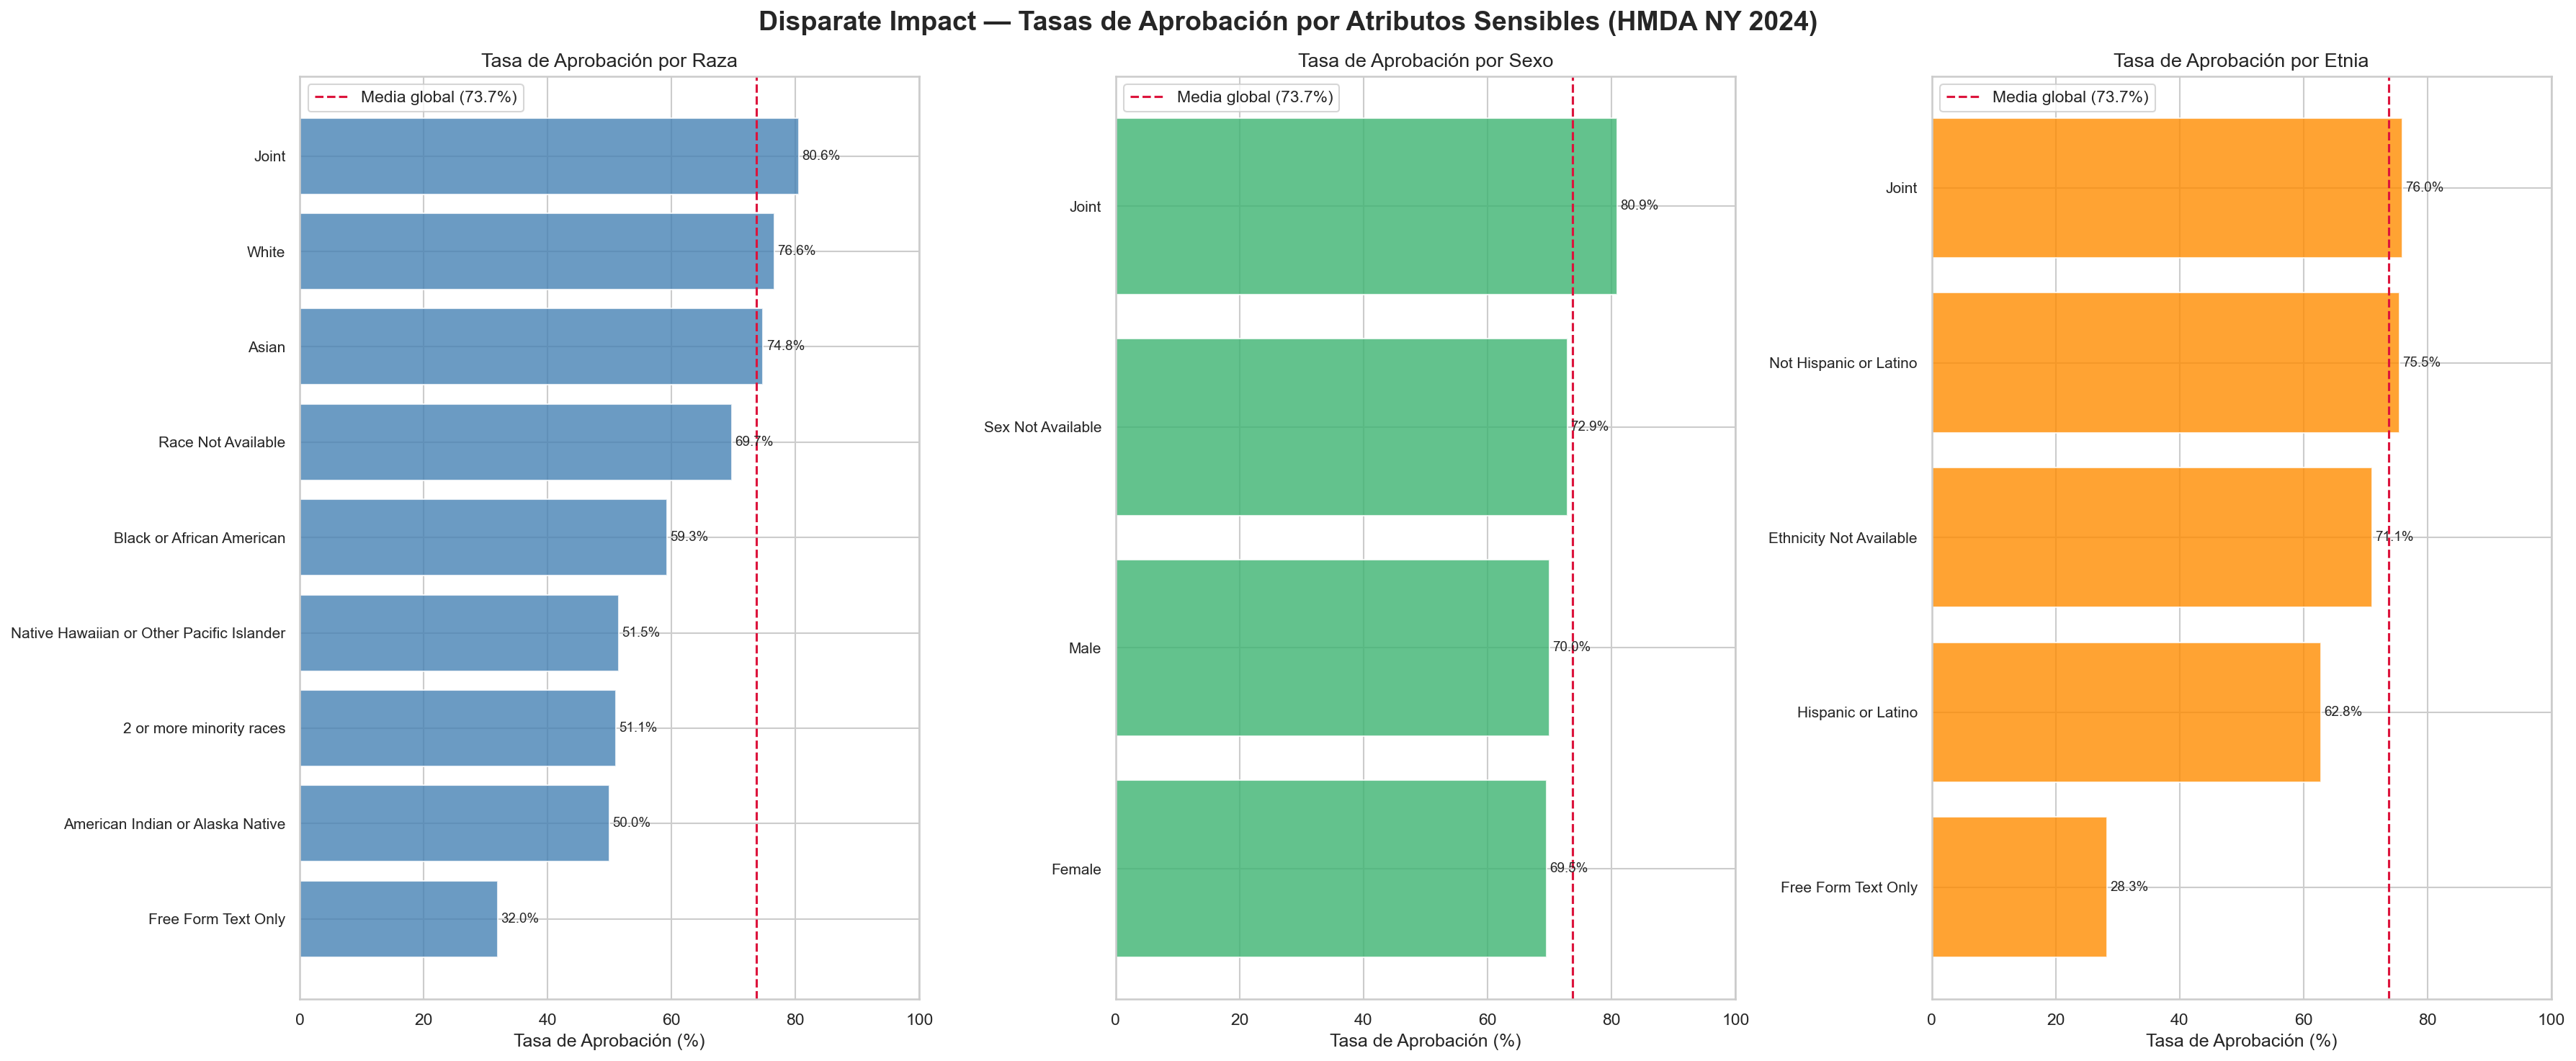

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(24, 10))

config_demografico = [
    ('derived_race',      'Raza',   'steelblue'),
    ('derived_sex',       'Sexo',   'mediumseagreen'),
    ('derived_ethnicity', 'Etnia',  'darkorange'),
]

for eje, (columna, titulo, color) in zip(ax, config_demografico):
    tasas = (df_base.groupby(columna)['action_taken']
             .mean()
             .sort_values()
             .dropna())
    
    # Eliminar la categoría "Not applicable" para claridad visual
    tasas = tasas[~tasas.index.str.contains('Not applicable|Information not provided', na=False)]
    
    barras = eje.barh(tasas.index, tasas.values * 100, color=color, alpha=0.8)
    
    # Línea de referencia: tasa global
    tasa_global = df_base['action_taken'].mean() * 100
    eje.axvline(tasa_global, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Media global ({tasa_global:.1f}%)')
    
    # Etiquetas de valor
    for barra, valor in zip(barras, tasas.values):
        eje.text(valor * 100 + 0.5, barra.get_y() + barra.get_height() / 2,
                 f'{valor*100:.1f}%', va='center', fontsize=9)
    
    eje.set_xlim(0, 100)
    eje.set_title(f'Tasa de Aprobación por {titulo}', fontsize=13)
    eje.set_xlabel('Tasa de Aprobación (%)')
    eje.legend(fontsize=11)
    eje.tick_params(axis='y', labelsize=10)

plt.suptitle('Disparate Impact — Tasas de Aprobación por Atributos Sensibles (HMDA NY 2024)',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/images/2_1_sesgo_demografico.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de Desbalanceo y Sesgo demográfico:**

* **Desbalanceo de la Decisión Final:** Confirmamos visualmente un claro desbalanceo de clases en nuestro *target*. Aproximadamente el 74% de las solicitudes son aprobadas frente a un 26% denegadas.

* **Sesgo Demográfico (Evidencia de Disparate Impact):**

    * **Por Raza:** Observamos diferencias de hasta 15-20% entre grupos.
    Los solicitantes que se identifican como *White* o *Asian* superan
    la media global, mientras que los grupos *Black or African American* y *American Indian
    or Alaska Native* quedan por debajo.

    * **Por Sexo:** La diferencia entre hombre y mujer, aunque menor, es observable y
    estadísticamente relevante dado el tamaño muestral. Una diferencia del 3-5% con
    aproximadamente 280.000 instancias tiene una potencia muy relevante.

    * **Por Etnia:** Los solicitantes *Hispanic or Latino* muestran tasas de aprobación
    inferiores a la media global, un patrón consistente con la literatura de *fairness*
    en crédito hipotecario en Estados Unidos.

**Lo que este análisis NO prueba todavía:** Las diferencias brutas no implican
causalidad directa. Un modelo puede mostrar *disparate impact* simplemente porque
los grupos minoritarios tienen, en promedio, distintos perfiles financieros
(ingresos, LTV, etc.). Distinguir sesgo estadístico de discriminación real es
exactamente la tarea de los notebooks siguientes con `Fairlearn` y `SHAP`. Aún así,
estas gráficas sirven como punto de partida de la detección de sesgo a realizar.

---
### Distribuciones Univariadas
Visualizar cómo se distribuye cada variable nos permite entender su forma real. En datos financieros, rara vez vemos una "campana de Gauss" perfecta. Lo habitual son distribuciones muy sesgadas a la derecha (mucha gente con ingresos medios, y muy poca con valores muy grandes). 

NOTA: Las herramientas de visualización ignoran los valores faltantes (NaNs) automáticamente para dibujarlas.

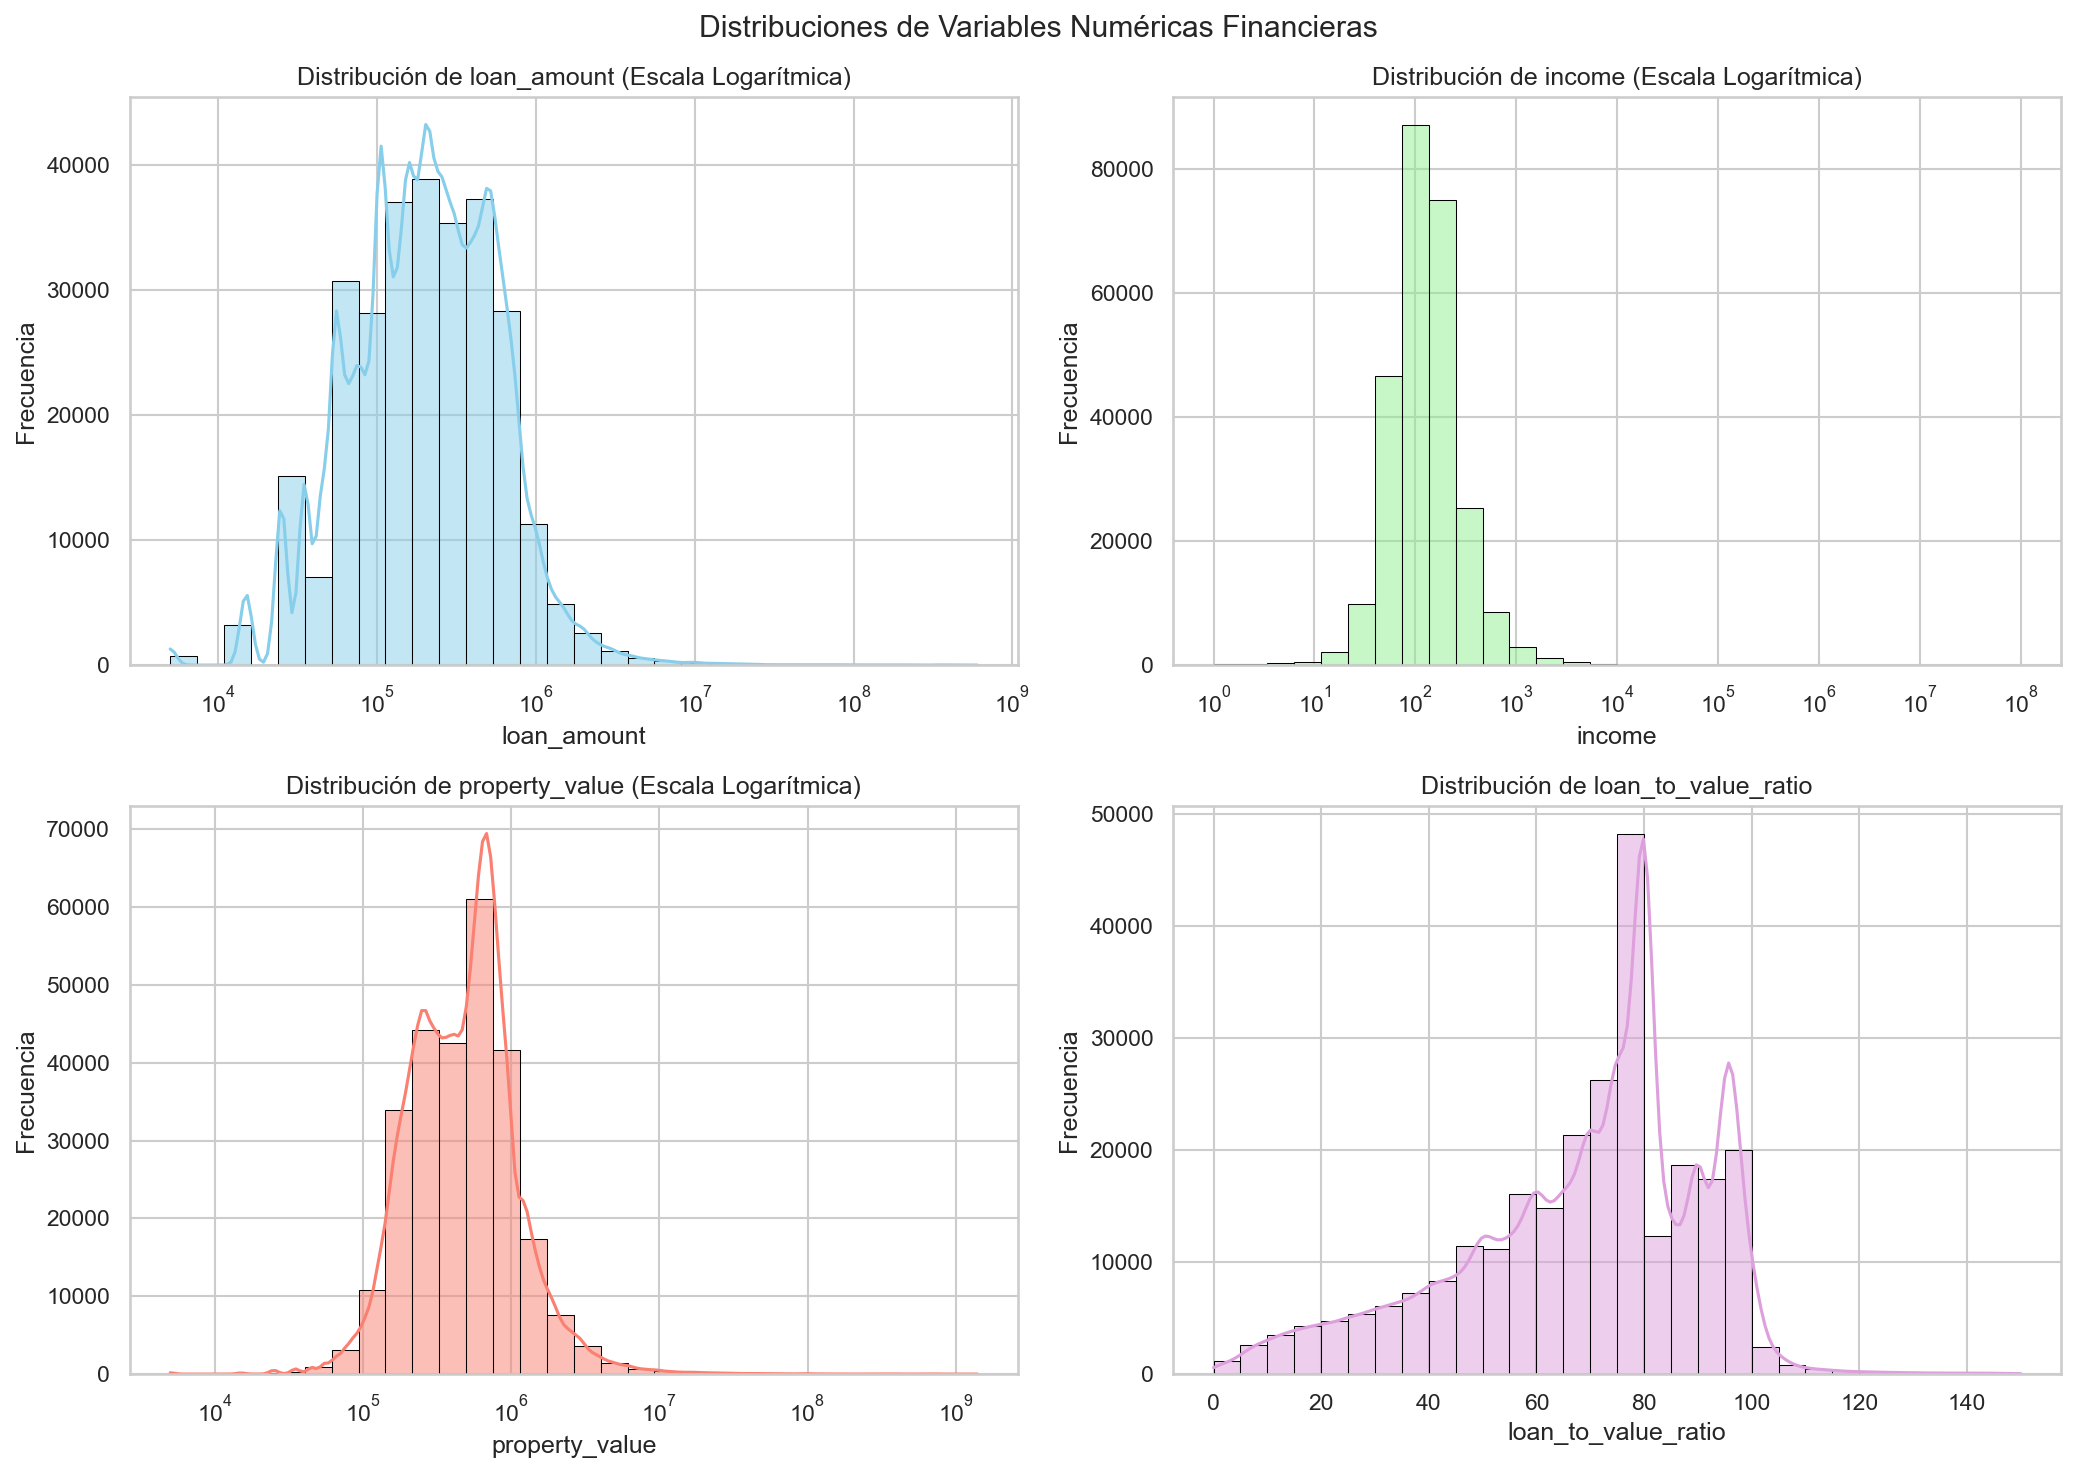

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colores = ['skyblue', 'lightgreen', 'salmon', 'plum']

fig.suptitle('Distribuciones de Variables Numéricas Financieras')

for indice, caracteristica in enumerate(caracteristicas_num_f):
    ax = axes[indice // 2, indice % 2]
    if caracteristica == 'loan_to_value_ratio':
        # Es necesario excluir los outliers en este caso para obtener una gráfica con resultados relevantes
        sns.histplot(data=df_base[df_base[caracteristica] <= 150], x=caracteristica, kde=True, bins=30, ax=ax, 
                color=colores[indice], edgecolor='black', linewidth=0.5)
        
        ax.set_title(f'Distribución de {caracteristica}')
        ax.set_ylabel('Frecuencia')
    else:
        # Usamos log_scale=True porque los datos financieros suelen tener colas muy largas
        sns.histplot(data=df_base, x=caracteristica, kde=True, bins=30, ax=ax, 
                color=colores[indice], log_scale=True, edgecolor='black', linewidth=0.5)
        
        ax.set_title(f'Distribución de {caracteristica} (Escala Logarítmica)')
        ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../outputs/images/2_2_distribuciones_univariadas_financieras.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de las Distribuciones Univariadas Financieras:**
* **Efectividad de la Escala Logarítmica:** Al aplicar el logaritmo, hemos logrado "descomprimir" visualmente el dataset. En su escala original, los valores atípicos multimillonarios habrían aplastado todos los gráficos contra el eje vertical. Ahora podemos observar la verdadera estructura de la masa principal de los datos.

* **Ingresos del Solicitante (`income`):** Observamos una distribución marcadamente acampanada (casi normal en el espacio logarítmico) con su pico centrado alrededor de $10^2$. Es crucial señalar aquí una particularidad del dataset HMDA: **los ingresos se reportan habitualmente en miles de dólares**. Por lo tanto, ese gran bloque central representa ingresos de unos 100.000$ anuales.

* **Préstamo y Propiedad (`loan_amount` y `property_value`):** Ambas variables muestran formas muy similares, lo cual es lógico ya que están íntimamente ligadas. El grueso del mercado se mueve entre $10^5$ (100.000$) y $10^6$ (1.000.000$). Notamos también pequeños "dientes de sierra" en el histograma del préstamo; esto refleja el comportamiento humano típico de solicitar cifras redondas (ej. pedir exactamente 200.000$ o 250.000$).

* **Ratio Préstamo/Valor (`loan_to_value_ratio`):** Representando en escala lineal (no logarítmica) y excluyendo el *outlier* irreal (2.000.000), el gráfico revela una distribución propia de las normativas bancarias. Destaca un **pico agudo entorno al 80%** (el estándar del mercado que exige un 20% de entrada), acompañado de **picos secundarios alrededor del 100%**. Esto demuestra que el banco aplica límites de riesgo estrictos, no graduales.

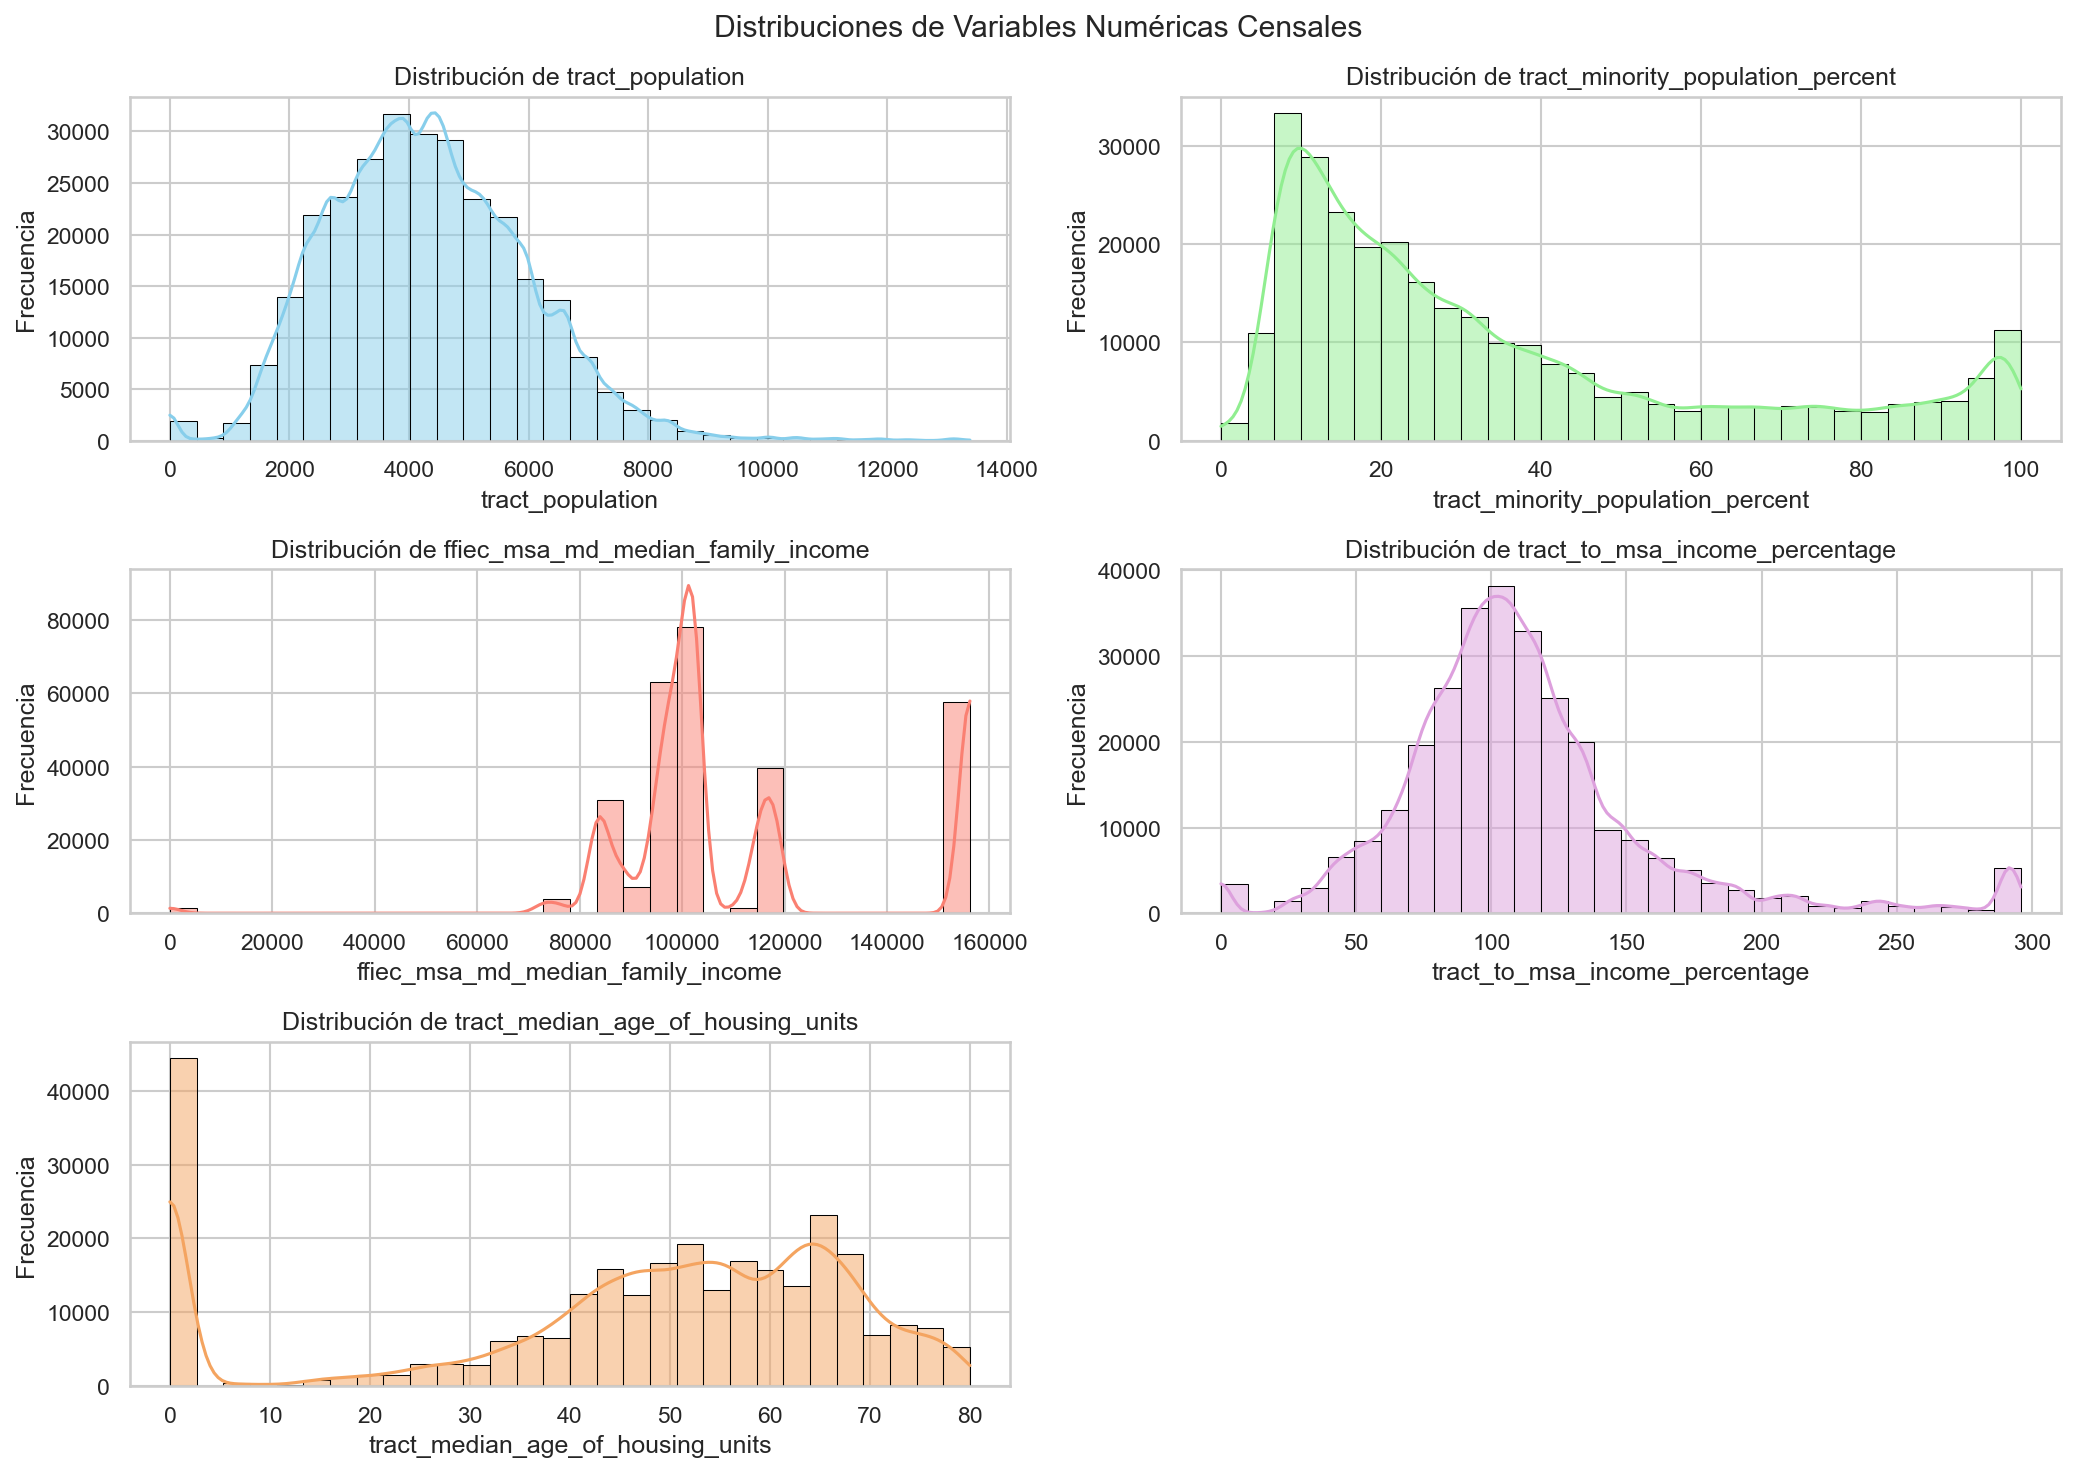

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
colores = ['skyblue', 'lightgreen', 'salmon', 'plum', 'sandybrown']

fig.suptitle('Distribuciones de Variables Numéricas Censales')

for indice, caracteristica in enumerate(caracteristicas_num_c):
        ax = axes[indice // 2, indice % 2]
    
        # Para datos censales: log_scale=False
        sns.histplot(data=df_base, x=caracteristica, kde=True, bins=30, ax=ax, 
                color=colores[indice], log_scale=False, edgecolor='black', linewidth=0.5)

        ax.set_title(f'Distribución de {caracteristica}')
        ax.set_ylabel('Frecuencia')

# Eliminamos el último cuadrante (Fila 3, Columna 2)
fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.savefig('../outputs/images/2_2_distribuciones_univariadas_censales.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de las Distribuciones Univariadas Censales:**

* **Población del Distrito (`tract_population`):** Presenta una distribución casi normal y simétrica centrada en torno a los 4.000/5.000 habitantes. Esto es coherente con el diseño demográfico del censo estadounidense, ya que los distritos geográficos (*tracts*) se delimitan a propósito para contener aproximadamente esa cuota de población.

* **Segregación Demográfica (`tract_minority_population_percent`):** Muestra un patrón asimétrico y bastante polarizado, lo cual es muy relevante para nuestro estudio de sesgos. Aunque hay una cantidad significativa de hipotecas en barrios habitados por minorías (valores entre 60% y 100%), la gran mayoría de los préstamos se ubican en zonas en las que la concentración es mucho menor (el pico se encuentra entre el 10% y el 20%). Esto evidencia una clara segregación urbana, donde las oportunidades de acceso al crédito inmobiliario están fuertemente desbalanceadas según la composición racial del barrio.

* **El Efecto de las Áreas Metropolitanas (`ffiec_msa_md_median_family_income`):** Su distribución muestra "agujas" o picos irregulares. Esto ocurre porque la variable funciona como un indicador macroeconómico: asigna el mismo valor de ingresos de referencia a todos los solicitantes de una misma área metropolitana, marcando el nivel de vida de esa región. Cada pico representa una zona metropolitana clave del estado (como la ciudad de Nueva York, Buffalo o Rochester).

* **Nivel Económico Relativo (`tract_to_msa_income_percentage`):** Muestra una curva normal acampanada con su centro muy cercano al 100%. Esto indica que la mayoría de los barrios analizados tienen ingresos acordes a la media general de su región. Las "colas" a ambos lados representan las zonas periféricas de extrema pobreza (por debajo del 50%) o de extrema riqueza (por encima del 200%).

* **Antigüedad del Parque Inmobiliario (`tract_median_age_of_housing_units`):** Destaca por dos grandes concentraciones en los extremos (ligeramente polarizadas). Presenta un pico masivo en el valor 0 (referido a propiedades a estrenar), seguido de un bloque central más "maduro" (50-60 años).

---
### Box Plots

Los Box Plots nos confirman visualmente la presencia masiva de valores atípicos (outliers) en la parte superior. 

En este contexto de negocio, debemos decidir si estos outliers son errores o datos reales. Por ejemplo, un solicitante con ingresos de varios millones de dólares es una realidad del mercado inmobiliario de Nueva York. 

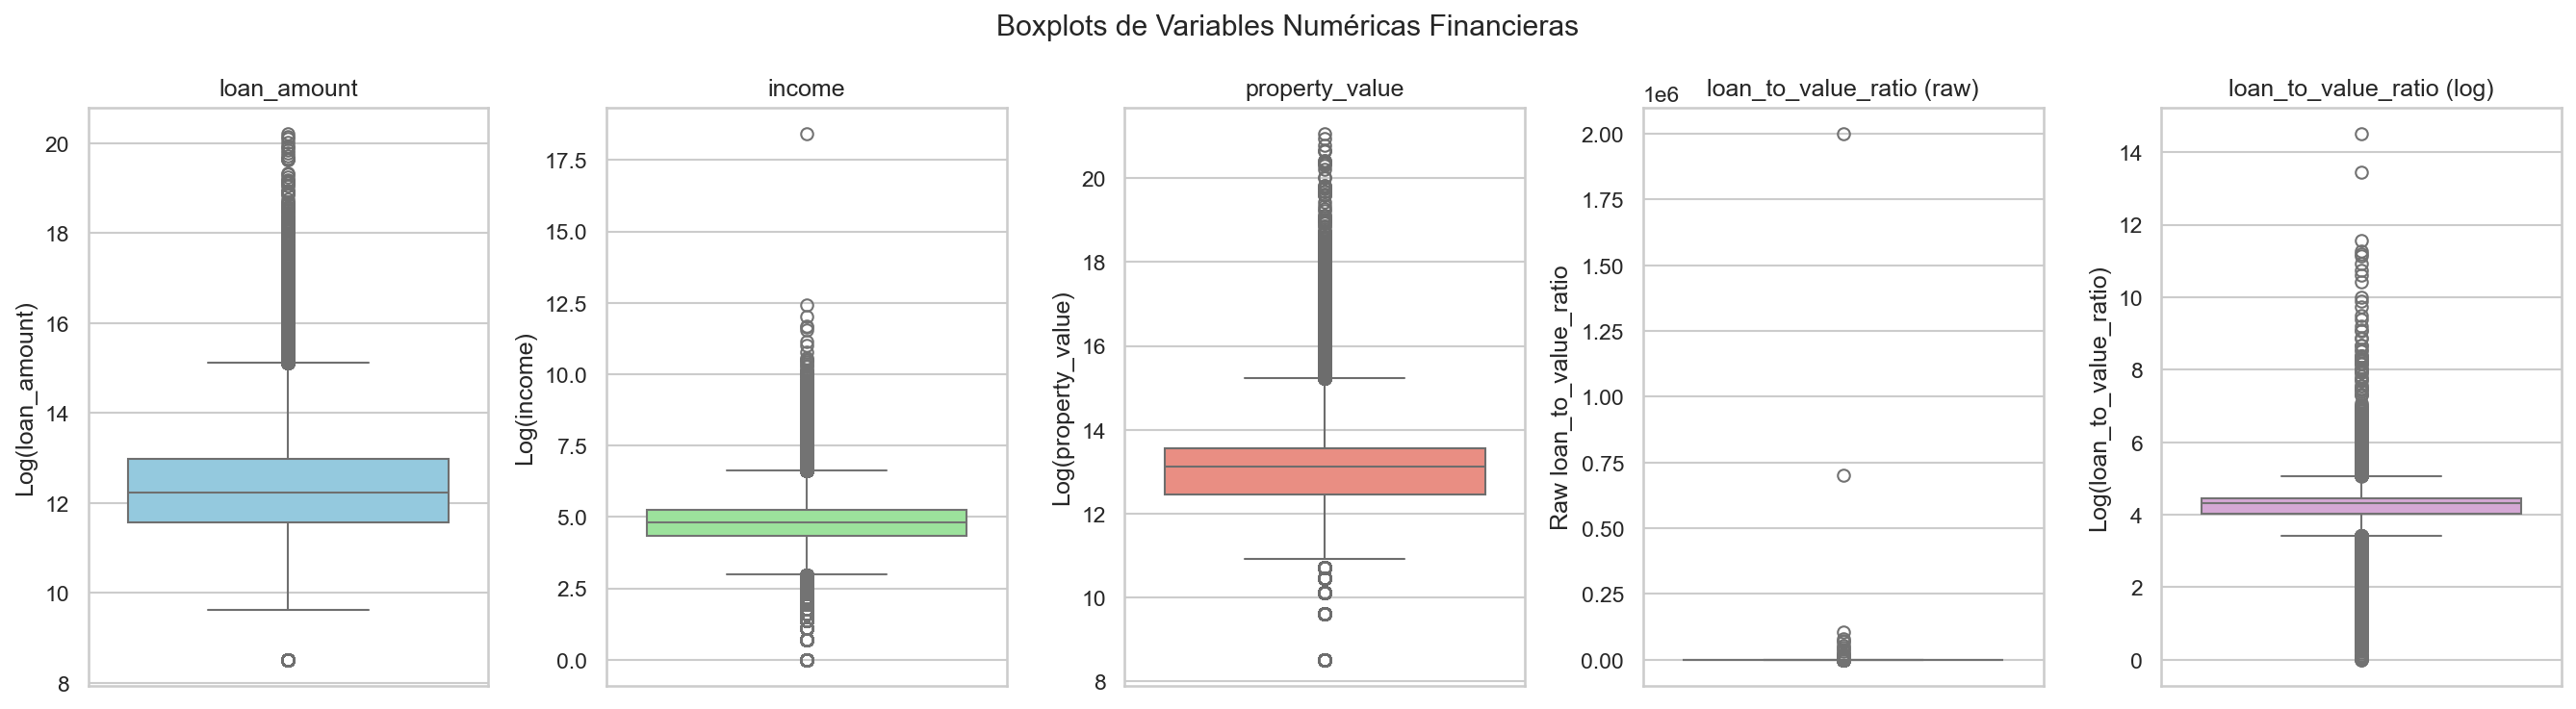

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

fig.suptitle('Boxplots de Variables Numéricas Financieras')

colores = ['skyblue', 'lightgreen', 'salmon', 'plum']

for indice, caracteristica in enumerate(caracteristicas_num_f):
    if caracteristica == 'loan_to_value_ratio':
        
        ax1 = axes[indice]
        ax2 = axes[indice+1]
    
        sns.boxplot(y=df_base[caracteristica], ax=ax1, color=colores[indice])
        sns.boxplot(y=np.log1p(df_base[caracteristica]), ax=ax2, color=colores[indice])

        ax1.set_title(f'{caracteristica} (raw)')
        ax1.set_ylabel(f'Raw {caracteristica}')
        ax2.set_title(f'{caracteristica} (log)')
        ax2.set_ylabel(f'Log({caracteristica})')

    else:
        ax = axes[indice]
        sns.boxplot(y=np.log1p(df_base[caracteristica]), ax=ax, color=colores[indice])
    
        ax.set_title(caracteristica)
        ax.set_ylabel(f'Log({caracteristica})')

plt.tight_layout()
plt.savefig('../outputs/images/2_3_box_plots_financieras.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de los Box Plots (Detección de Outliers) en Variables Financieras:**

* **Efecto de la Transformación Logarítmica:** Al aplicar el logaritmo (`np.log1p`), las "cajas" (el rango intercuartílico que contiene al 50% central de los datos) de las variables monetarias por fin son claramente legibles. Sin embargo, incluso en esta escala comprimida, observamos una cantidad inmensa de valores "atípicos" (los círculos fuera de los bigotes).

* **Variables de Capital (`loan_amount` y `property_value`):** Ambas presentan una gran cantidad de *outliers* en la parte superior. Lejos de ser errores de captura, estos puntos validan la realidad del estado de Nueva York: un mercado de contrastes donde se peuden encontrar tanto hipotecas residenciales estándar como operaciones inmobiliarias lujosas o edificios comerciales.

* **Ingresos del Solicitante (`income`):** Llama la atención la presencia de *outliers* en ambos extremos. Los puntos superiores (por encima de la caja verde) corresponden a individuos con un altísimo patrimonio. Por otro lado, los puntos inferiores se alinean con nuestra detección previa en la estadística descriptiva: solicitantes que reportaron ingresos mínimos, nulos o pérdidas.

* **El colapso del LTV (`loan_to_value_ratio`):** La comparativa entre el gráfico en bruto (*raw*) y el logarítmico (*log*) es la prueba visual definitiva del efecto destructivo de los grandes *outliers*. En el gráfico *raw*, el 99% de los datos se comprime en una línea invisible en la base debido al valor anómalo de 2.000.000. Al visualizar su versión logarítmica, recuperamos la caja central, revelando una dispersión masiva de valores anómalos tanto por encima como por debajo de los límites estándar del mercado.

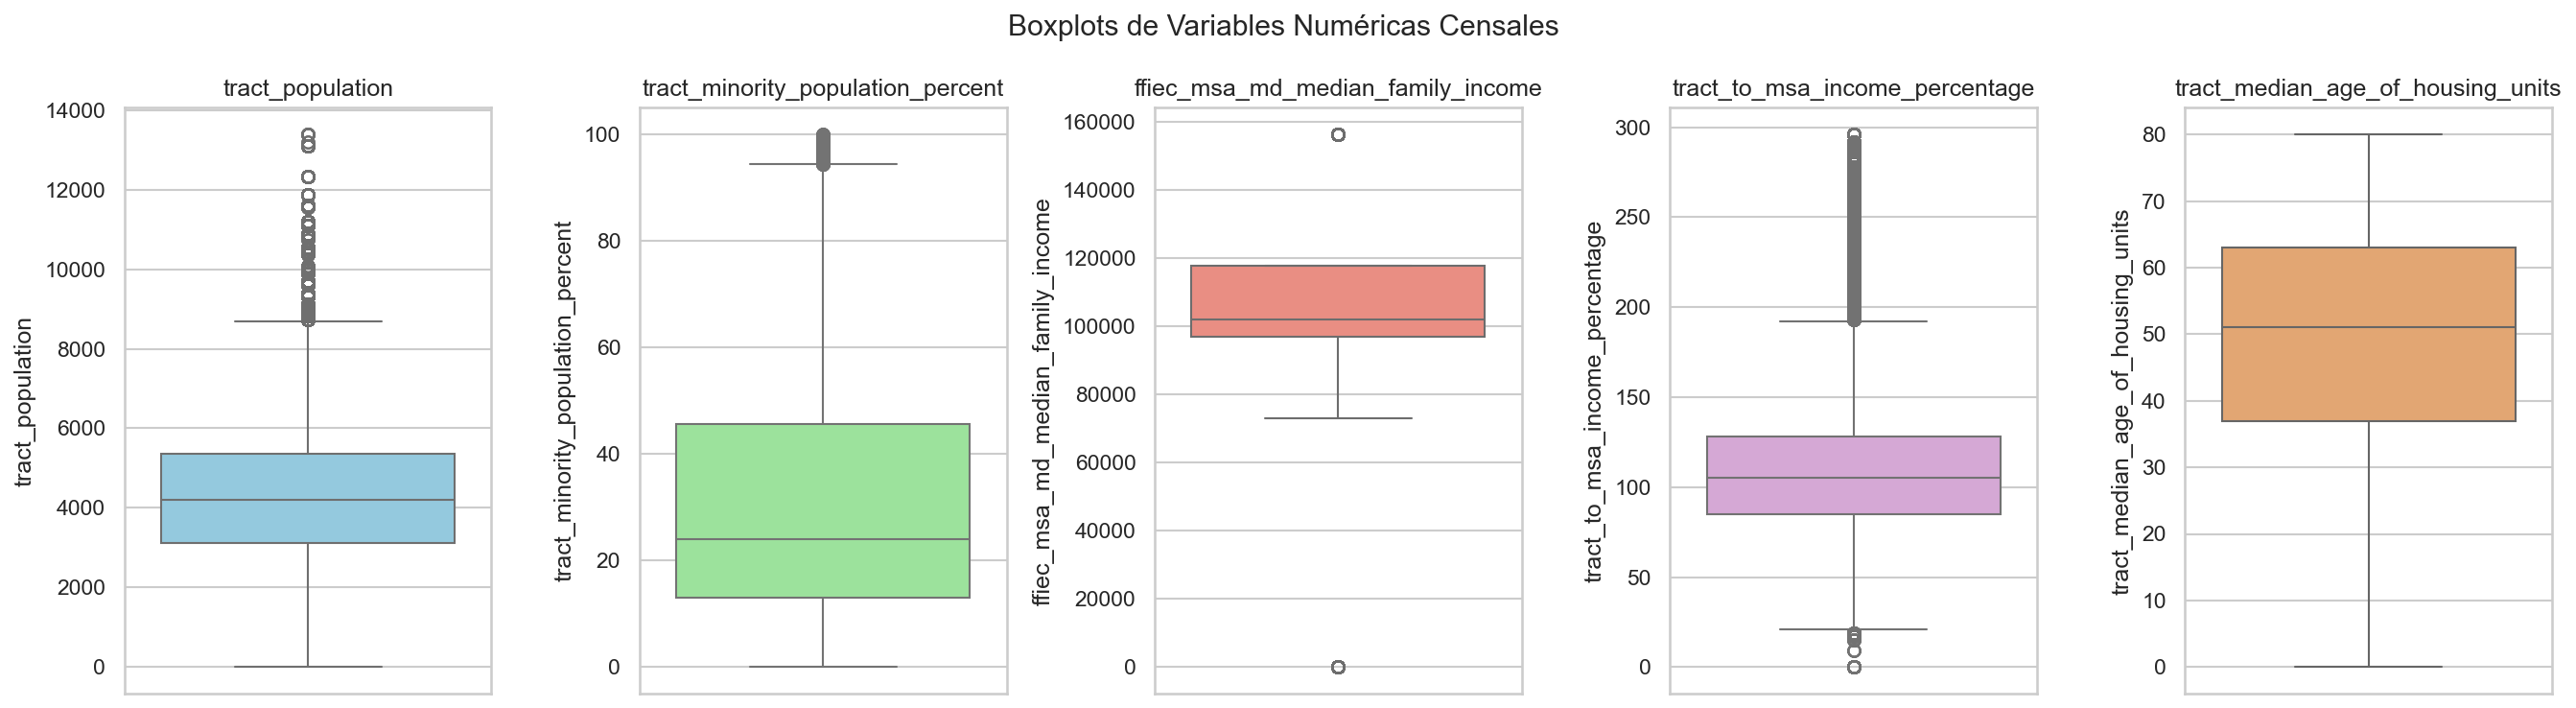

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

fig.suptitle('Boxplots de Variables Numéricas Censales')

colores = ['skyblue', 'lightgreen', 'salmon', 'plum', 'sandybrown']

for indice, caracteristica in enumerate(caracteristicas_num_c):
    ax = axes[indice]
    sns.boxplot(y=df_base[caracteristica], ax=ax, color=colores[indice])

    ax.set_title(caracteristica)

plt.tight_layout()
plt.savefig('../outputs/images/2_3_box_plots_censales.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretación de los Box Plots (Detección de Outliers) en Variables Censales:**

* **Densidad Urbana (`tract_population`):** La caja central confirma que el diseño demográfico estándar agrupa a la mayoría de los distritos entre los 3.000 y 5.000 habitantes. Sin embargo, la larga cola de *outliers* superiores refleja la existencia de zonas de altísima densidad poblacional, capturando a la perfección las dinámicas urbanas de grandes ciudades como Nueva York.

* **Diversidad y Segregación (`tract_minority_population_percent`):** La caja es significativamente amplia (reflejando gran variabilidad demográfica general), pero lo más destacable son los *outliers* cerca del 100%. Estos puntos reafirman lo que ya detectamos en las distribuciones univariadas: la existencia de barrios "hipersegregados" (punto relevante a tener en cuenta en el análisis de sesgos).

* **El Indicador Macro (`ffiec_msa_md_median_family_income`):** Su caja carece casi por completo de la dispersión de *outliers* típica de las variables financieras. Los únicos valores atípicos son puntos muy concretos, incluyendo un valor anómalo de 0. Esta "rigidez" visual corrobora que se trata de un valor regional precalculado, no de una métrica granular de cada barrio.

* **Desigualdad Intrarregional (`tract_to_msa_income_percentage`):** Aunque la mediana se sitúa lógicamente cerca del 100% (el barrio cobra lo mismo que la media de su área metropolitana), la inmensa y densa columna de *outliers* superiores es muy reveladora. Identifica de forma clara la presencia de zonas residenciales de extrema riqueza, donde el nivel de ingresos del vecindario triplica (rozando el 300%) la media de su propia región.

* **El Tope Artificial del Censo (`tract_median_age_of_housing_units`):** El hallazgo más crítico de este gráfico es puramente técnico. Llama la atención la ausencia absoluta de *outliers* en la parte superior y el corte del bigote exactamente en la marca de 80 años. Esto confirma que el dataset está aplicando un "techo", agrupando todas las propiedades históricas bajo el valor máximo de 80 años.

**Decisión Metodológica Definitiva (Síntesis Financiera y Censal):** Excluyendo únicamente los errores informáticos evidentes (como el LTV > 150% o el límite artificial de antigüedad de las casas de 80 años), se puede confirmar que **conservaremos todos los valores atípicos restantes**.
* **A nivel financiero:** Eliminar los extremos monetarios significaría "mutilar" la realidad económica de Nueva York, ignorando sus enormes contrastes de capital.
* **A nivel censal:** Suprimir los *outliers* demográficos (como los enclaves de extrema riqueza o los barrios hipersegregados al 100% de minorías) destruiría la base necesaria para nuestro futuro análisis de equidad algorítmica y sesgos.

En conclusión, la presencia masiva de esta extrema varianza real justifica de forma rotunda nuestra decisión de priorizar algoritmos basados en árboles (como Gradient Boosting). A diferencia de los modelos lineales clásicos, estos algoritmos no se ven arrastrados matemáticamente por los *outliers*, lo que nos permitirá modelar esta compleja realidad socioeconómica sin añadir más sesgos de los que ya hay.


---
### Correlaciones (previo)

Calculamos la matriz de correlación de Pearson (estándar) para obtener una primera aproximación de las relaciones lineales entre variables. Para ello, seleccionamos las variables numéricas más representativas (financieras) junto con aquellas sensibles al sesgo. Estas últimas, al ser categóricas, se codifican numéricamente de manera puntual para valorar su impacto.

**Limitación importante:** Pearson es extremadamente sensible a outliers. Dado que el EDA ha revelado valores extremos masivos en las variables numéricas financieras (`loan_amount`, `income` ,`property_value`, `loan_to_value_ratio`), algunas correlaciones aparecerán artificialmente cercanas a 0 aunque la relación real sea significativa. Esto se demostrará y corregirá en la sección de Preprocesamiento, donde compararemos esta misma matriz antes y después de la transformación logarítmica.

In [18]:
# Codificación variables sensibles
le = LabelEncoder()

df_corr = df_base.copy()
cols_categoricas = ['derived_race', 'derived_sex', 'derived_ethnicity']

for col in cols_categoricas:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

                     loan_amount    income  property_value  \
loan_amount             1.000000  0.000777        0.683440   
income                  0.000777  1.000000       -0.000056   
property_value          0.683440 -0.000056        1.000000   
loan_to_value_ratio    -0.000257  0.000063       -0.000531   
derived_race           -0.005681 -0.003451       -0.005114   
derived_sex             0.052399  0.001864        0.040389   
derived_ethnicity      -0.056934  0.000960       -0.045299   
action_taken            0.013171 -0.003139        0.001266   

                     loan_to_value_ratio  derived_race  derived_sex  \
loan_amount                    -0.000257     -0.005681     0.052399   
income                          0.000063     -0.003451     0.001864   
property_value                 -0.000531     -0.005114     0.040389   
loan_to_value_ratio             1.000000     -0.003258    -0.003803   
derived_race                   -0.003258      1.000000     0.044238   
derived_sex    

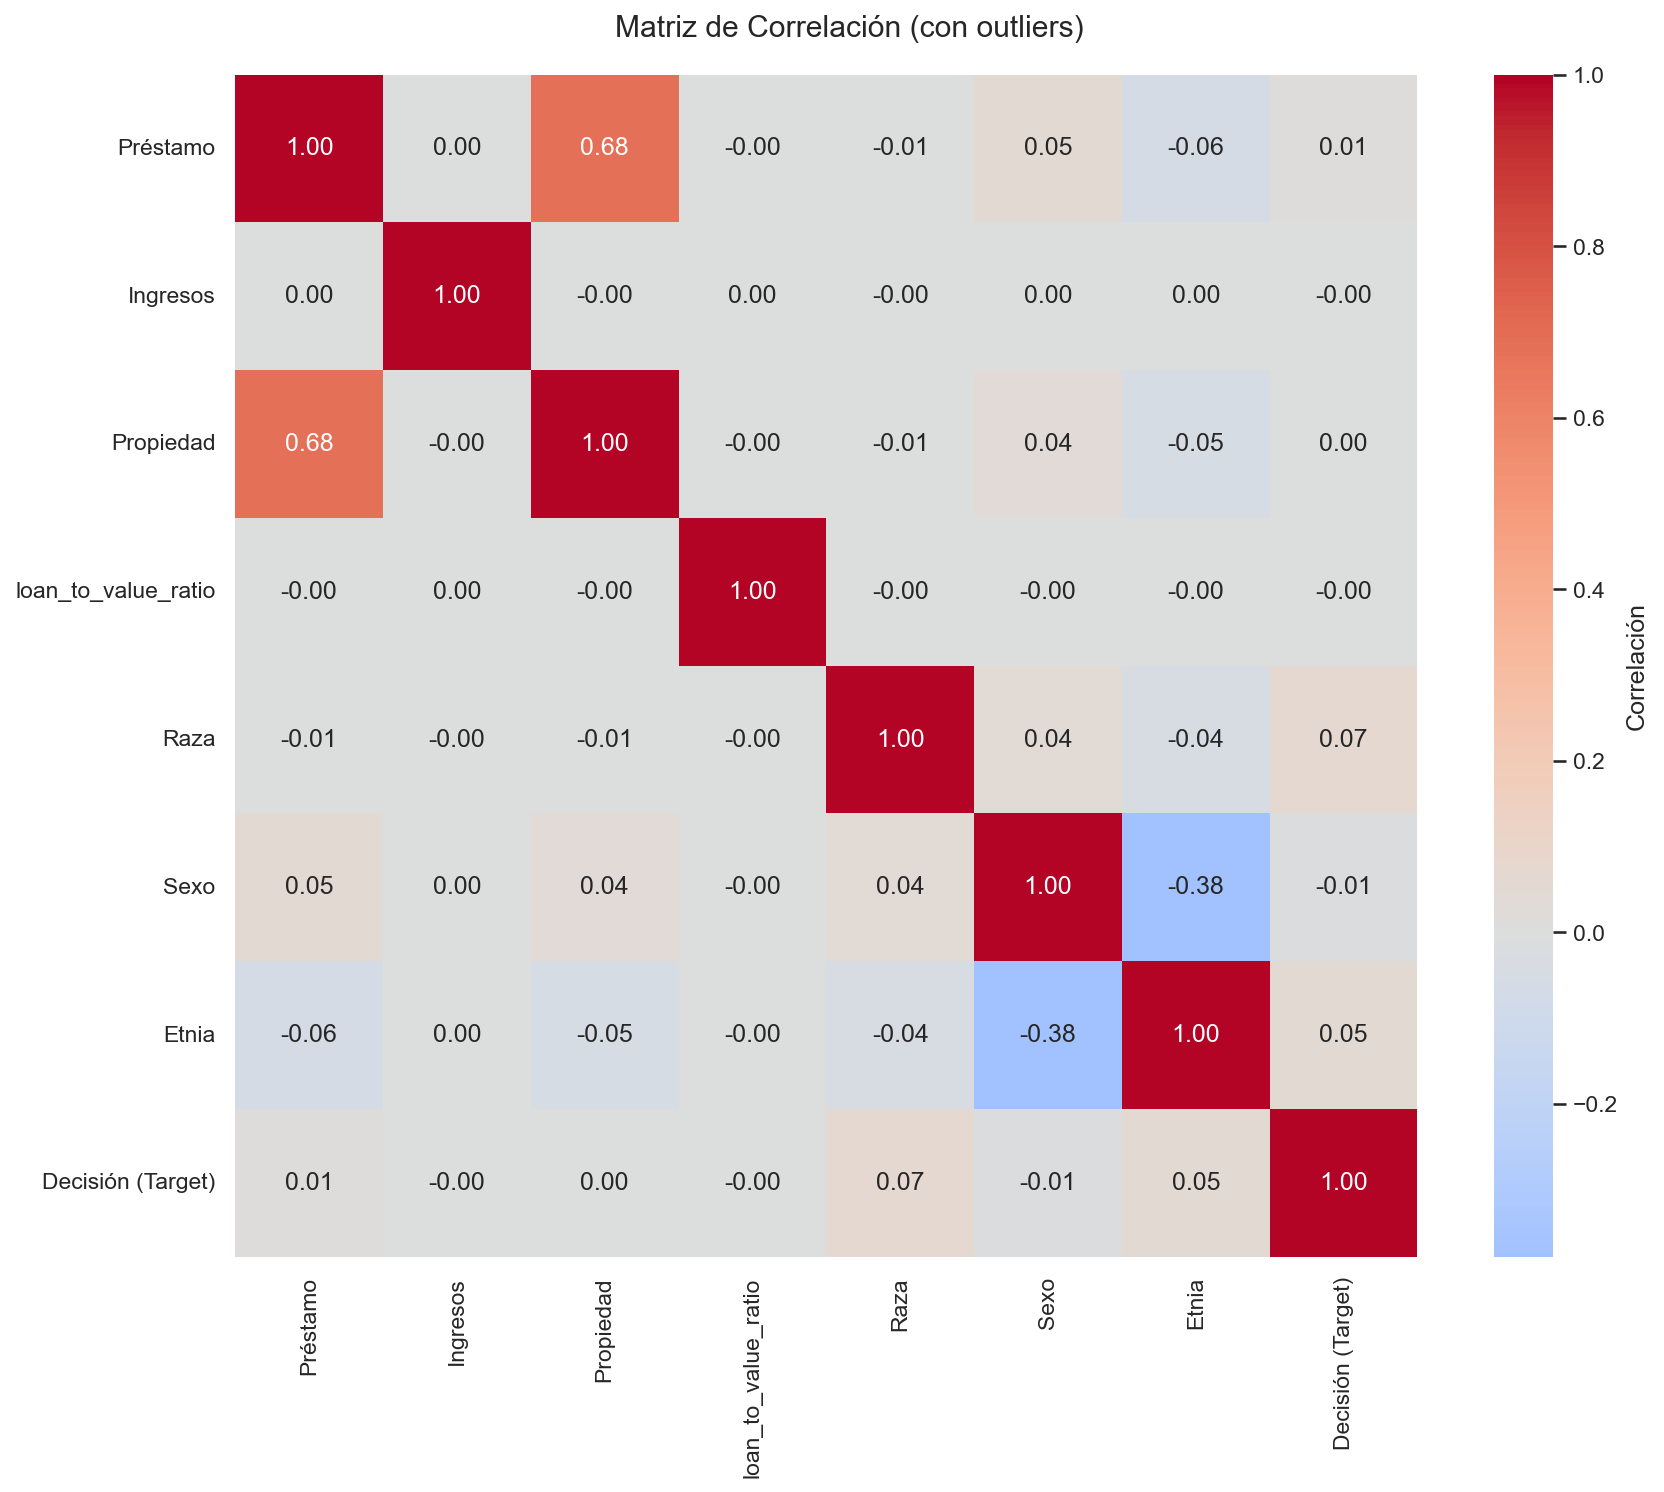

In [19]:
# Selección de columnas
cols_correlacion = caracteristicas_num_f + cols_categoricas + ['action_taken']

matriz_corr  = df_corr[cols_correlacion].corr()
print(matriz_corr)

# Traducción de etiquetas
nombres_corr = {
    'loan_amount': 'Préstamo',
    'income': 'Ingresos',
    'property_value': 'Propiedad',
    'interest_rate': 'Interés',
    'derived_race': 'Raza',
    'derived_sex': 'Sexo', 
    'derived_ethnicity': 'Etnia',
    'action_taken': 'Decisión (Target)'
}
matriz_corr.index   = [nombres_corr.get(c, c) for c in matriz_corr.index]
matriz_corr.columns = [nombres_corr.get(c, c) for c in matriz_corr.columns]

# Visualización
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax, cbar_kws={'label': 'Correlación'})
fig.suptitle('Matriz de Correlación (con outliers)')
plt.tight_layout()
plt.savefig('../outputs/images/2_4_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

---
---

## Preprocesamiento (Parte 1)

---
### Filtrado de Columnas

In [20]:
df_base = pd.read_csv('../data/hmda_base.csv')

#### Eliminación de Identificadores y Constantes

Para comenzar con el filtrado de columnas, hemos decidido eliminar variables que son identificadores constantes que solo introducen ruido en el modelo. Estas son las columnas a eliminar:

* `activity_year`: constante, solo contiene 2024.
* `state_code`: constante, solo contiene NY.
* `lei`: identificador único de la entidad financiera. El modelo memorizaría qué bancos aprueban más en vez de aprender el perfil del solicitante.
* `census_tract`: alta cardinalidad (miles de códigos). La información geográfica relevante ya está capturada por `county_code` (código del condado general) y las variables del censo.

In [21]:
# Columnas identificadores y constantes 
cols_identificadores = [
    'activity_year',   
    'state_code',      
    'lei',             
    'census_tract',    
]

#### Corrección del *Data Leakage*

Por otro lado, el *data leakage* ocurre cuando el modelo accede durante el entrenamiento a información
que no estaría disponible en el momento real de la predicción. Es el error metodológico
más grave en ML: produce métricas de entrenamiento excelentes pero modelos inútiles
en producción.

Para corregir este problema, debemos eliminar aquellas columnas que se pueden considerar "consecuencias" de la decisión tomada:

* **Razones de denegación.** Solo existen *después* de la decisión negativa.

  * `denial_reason-1`
  * `denial_reason-2`
  * `denial_reason-3`
  * `denial_reason-4`

* **Condiciones financieras finales.** Solo existen si se aprueba.

  * `interest_rate`
  * `rate_spread`
  * `hoepa_status`

* **Costes de formalización y cierre.** Gastos de notaría/banco (posteriores a la decisión).

  * `total_loan_costs`
  * `total_points_and_fees`
  * `origination_charges`
  * `discount_points`
  * `lender_credits`

* **Eventos post-concesión.** Venta a otra entidad.

  * `purchaser_type`


In [22]:
# Columnas con leakage
cols_leakage = [
    'denial_reason-1', 'denial_reason-2', 'denial_reason-3', 'denial_reason-4',
    'interest_rate', 'rate_spread', 'hoepa_status', 
    'total_loan_costs', 'total_points_and_fees', 'origination_charges', 
    'discount_points', 'lender_credits', 'purchaser_type'
]

In [23]:
# Filtrado
cols_eliminar = [c for c in cols_leakage + cols_identificadores 
                 if c in df_base.columns]

df_filtrado = df_base.drop(columns=cols_eliminar)

print(f"Shape antes:   {df_base.shape}")
print(f"Shape después: {df_filtrado.shape}")
print(f"Columnas eliminadas: {df_base.shape[1] - df_filtrado.shape[1]}")

df_filtrado.to_csv('../data/hmda_filtrado.csv', index=False)

Shape antes:   (283332, 99)
Shape después: (283332, 82)
Columnas eliminadas: 17


---
### Codificación de Variables Categóricas

In [24]:
df_filtrado = pd.read_csv('../data/hmda_filtrado.csv')
df_filtrado_original = df_filtrado.copy()

Tras el filtrado, disponemos de un conjunto de variables de diversa naturaleza. Para que los algoritmos de Machine Learning puedan procesar esta información, es necesario transformar las categorías textuales en valores numéricos.

Para este proyecto, hemos rechazado el uso de una codificación uniforme (como un *One-Hot Encoding* masivo) para evitar la "maldición de la dimensionalidad" y la pérdida de jerarquías lógicas. En su lugar, aplicaremos estrategias de codificación diferenciadas basadas en cuatro grupos:

1. **Numéricas con "*Exempt*":** Columnas categóricas codificadas en el origen, pero con formato *object* debido a que incluyen un valor "*Exempt*" en lugar de nulos (por ejemplo: `loan_term` o `intro_rate_period`). Se transformarán a tipo `float`, tratando esos valores no numéricos como nulos (posterior imputación).

2. **Variables Ordinales:** Variables con un orden intrínseco (como `applicant_age` o `debt_to_income_ratio`) se codificarán mediante *LabelEncoding*; aunque se usará el mapeo para asegurar el mantenimiento de la relación de magnitud entre posibles valores.

3. **Codificación Binaria (0/1):** Para variables binarias como `applicant_age_above_62`, se utilizará un mapeo simple.

4. **Variables Nominales:** Para categorías puras sin orden (como `derived_race` o `derived_sex`), se recurrirá al *One-Hot Encoding*. Esto evita que el modelo asuma falsas relaciones matemáticas de jerarquía entre etiquetas.

In [25]:
# Codificación del Grupo 1: Numéricas con "Exempt"

cols_exempt = [
    'loan_term', 
    'prepayment_penalty_term', 
    'intro_rate_period', 
    'multifamily_affordable_units'
]

print("=" * 40)
print("ANTES")
print("=" * 40)
print(df_filtrado[cols_exempt].dtypes)
valores_exempt = df_filtrado[cols_exempt].isnull().sum()

# errors='coerce' pone un NaN si no puede convertir a número (ej. "Exempt")
for col in cols_exempt:
    df_filtrado[col] = pd.to_numeric(df_filtrado[col], errors='coerce')

print("\n"+"=" * 40)
print("DESPUÉS")
print("=" * 40)
print(df_filtrado[cols_exempt].dtypes)

# Aumento de valores nulos
print("\n"+"-" * 40)
print("Nulos generados (valores Exempt):")
print("-" * 40)
print(df_filtrado[cols_exempt].isnull().sum() - valores_exempt)

ANTES
loan_term                       object
prepayment_penalty_term         object
intro_rate_period               object
multifamily_affordable_units    object
dtype: object

DESPUÉS
loan_term                       float64
prepayment_penalty_term         float64
intro_rate_period               float64
multifamily_affordable_units    float64
dtype: object

----------------------------------------
Nulos generados (valores Exempt):
----------------------------------------
loan_term                       7968
prepayment_penalty_term         8326
intro_rate_period               8307
multifamily_affordable_units    8313
dtype: int64


In [26]:
# Codificación del Grupo 2: Variables ordinales

cols_ordinales = ['applicant_age', 'co-applicant_age', 'debt_to_income_ratio', 'total_units']

print("=" * 31)
print("ANTES")
print("=" * 31)
print(df_filtrado[cols_ordinales].dtypes)
nulos_ord = df_filtrado[cols_ordinales].isnull().sum()

# Diccionarios para el mapeo jerárquico
mapa_age = {
    '<25': 1,
    '25-34': 2,
    '35-44': 3,
    '45-54': 4,
    '55-64': 5,
    '65-74': 6,
    '>74': 7,
    '8888': np.nan, # código para "No aplicable"
    '9999': np.nan  # código para "Desconocido"
}
mapa_dti = {
    '<20%': 1,
    '20%-<30%': 2,
    '30%-<36%': 3,
    '36': 4, '37': 5, '38': 6, '39': 7, '40': 8,
    '41': 9, '42': 10, '43': 11, '44': 12, '45': 13,
    '46': 14, '47': 15, '48': 16, '49': 17,
    '50%-60%': 18,
    '>60%': 19,
    'Exempt': np.nan
}
mapa_units = {
    '1': 1, '2': 2, '3': 3, '4': 4,
    '5-24': 5,
    '25-49': 6,
    '50-99': 7,
    '100-149': 8,
    '>149': 9
}

# Aplicar mapeo
df_filtrado['applicant_age'] = df_filtrado['applicant_age'].map(mapa_age)
df_filtrado['co-applicant_age'] = df_filtrado['co-applicant_age'].map(mapa_age)
df_filtrado['debt_to_income_ratio'] = df_filtrado['debt_to_income_ratio'].map(mapa_dti)
df_filtrado['total_units'] = df_filtrado['total_units'].map(mapa_units)


print("\n"+"=" * 31)
print("DESPUÉS")
print("=" * 31)
print(df_filtrado[cols_ordinales].dtypes)

# Aumento de valores nulos
print("\n"+"-" * 55)
print("Nulos generados (8888 y 9999 en age y Exempt en dti):")
print("-" * 55)
print(df_filtrado[cols_ordinales].isnull().sum() - nulos_ord)

ANTES
applicant_age           object
co-applicant_age        object
debt_to_income_ratio    object
total_units             object
dtype: object

DESPUÉS
applicant_age           float64
co-applicant_age        float64
debt_to_income_ratio    float64
total_units             float64
dtype: object

-------------------------------------------------------
Nulos generados (8888 y 9999 en age y Exempt en dti):
-------------------------------------------------------
applicant_age            10232
co-applicant_age        173295
debt_to_income_ratio      8307
total_units               8192
dtype: int64


In [27]:
# Codificación del Grupo 3: Variables ordinales

# Columnas binarias a codificar
cols_binarias = [
    'applicant_age_above_62', 
    'co-applicant_age_above_62'
]

# Corrección de variables binarias mal codificadas de origen
cols_binarias_mal = [
    'reverse_mortgage', 
    'open-end_line_of_credit', 
    'business_or_commercial_purpose', 
    'submission_of_application', 
    'initially_payable_to_institution'
]

cols_grupo_3 = cols_binarias + cols_binarias_mal

print("\n"+"-" * 40)
print("Valores únicos antes de la conversión:")
print("-" * 40)
for col in cols_grupo_3:
    print(f"{col}: {df_filtrado[col].unique()}")

# Diccionarios de mapeo
mapa_binario = {'Yes': 1, 'No': 0}
mapa_binario_correccion = {
    1: 1, 
    2: 0,
    1111: np.nan, # código HMDA para "Exempt"
    8888: np.nan  # código HMDA para "Not applicable"
}

# Aplicación
for col in cols_binarias:
    df_filtrado[col] = df_filtrado[col].map(mapa_binario)

for col in cols_binarias_mal:
    df_filtrado[col] = df_filtrado[col].map(mapa_binario_correccion)

print("\n"+"-" * 40)
print("Valores únicos tras la conversión:")
print("-" * 40)
for col in cols_grupo_3:
    print(f"{col}: {df_filtrado[col].unique()}")


----------------------------------------
Valores únicos antes de la conversión:
----------------------------------------
applicant_age_above_62: ['No' 'Yes' nan]
co-applicant_age_above_62: ['No' nan 'Yes']
reverse_mortgage: [   2 1111    1]
open-end_line_of_credit: [   2 1111    1]
business_or_commercial_purpose: [   2 1111    1]
submission_of_application: [   1 1111    2]
initially_payable_to_institution: [   1 1111    3    2]

----------------------------------------
Valores únicos tras la conversión:
----------------------------------------
applicant_age_above_62: [ 0.  1. nan]
co-applicant_age_above_62: [ 0. nan  1.]
reverse_mortgage: [ 0. nan  1.]
open-end_line_of_credit: [ 0. nan  1.]
business_or_commercial_purpose: [ 0. nan  1.]
submission_of_application: [ 1. nan  0.]
initially_payable_to_institution: [ 1. nan  0.]


In [28]:
# Codificación del Grupo 4: Variables nominales

cols_nominales = [
    'conforming_loan_limit', 'derived_loan_product_type', 
    'derived_dwelling_category', 'derived_ethnicity', 
    'derived_race', 'derived_sex'
]

print("=" * 40)
print("ANTES")
print("=" * 40)
print(df_filtrado[cols_nominales].dtypes)

# One-Hot Encoding
df_codificado = pd.get_dummies(df_filtrado, columns=[str(col) for col in cols_nominales], drop_first=False)
columnas_one_hot = [col for col in df_codificado.columns if col not in df_filtrado.columns]

print("\n"+"=" * 40)
print("DESPUÉS")
print("=" * 40)
print(df_codificado[columnas_one_hot].dtypes)

ANTES
conforming_loan_limit        object
derived_loan_product_type    object
derived_dwelling_category    object
derived_ethnicity            object
derived_race                 object
derived_sex                  object
dtype: object

DESPUÉS
conforming_loan_limit_C                                             bool
conforming_loan_limit_NC                                            bool
conforming_loan_limit_U                                             bool
derived_loan_product_type_Conventional:First Lien                   bool
derived_loan_product_type_Conventional:Subordinate Lien             bool
derived_loan_product_type_FHA:First Lien                            bool
derived_loan_product_type_FHA:Subordinate Lien                      bool
derived_loan_product_type_FSA/RHS:First Lien                        bool
derived_loan_product_type_FSA/RHS:Subordinate Lien                  bool
derived_loan_product_type_VA:First Lien                             bool
derived_dwelling_category

In [29]:
print("*" * 50)
print("COMPARATIVA FINAL DE LA CODIFICACIÓN")
print("*" * 50)

print(f"Nº columnas:")
print(f"  - Antes:   {df_filtrado_original.shape[1]}")
print(f"  - Después: {df_codificado.shape[1]}")

print(f"\nTipos de datos:")
print(f"  - Antes:   {df_filtrado_original.dtypes.unique()}")
print(f"  - Después: {df_codificado.dtypes.unique()}")

**************************************************
COMPARATIVA FINAL DE LA CODIFICACIÓN
**************************************************
Nº columnas:
  - Antes:   82
  - Después: 108

Tipos de datos:
  - Antes:   [dtype('int64') dtype('float64') dtype('O')]
  - Después: [dtype('int64') dtype('float64') dtype('O') dtype('bool')]


Con esto, podemos dar por concluida la codificación del dataset, con la desaparición absoluta de columnas categóricas (`object`). Este proceso ha generado una ligera "expansión dimensional", pasando de 82 a 108 columnas como resultado directo de aplicar el *One-Hot Encoding*. Gracias a esta técnica, las variables nominales complejas se han desglosado en atributos booleanos independientes, lo que previene que el modelo asuma falsas jerarquías matemáticas. En consecuencia, el dataset presenta ahora una estructura puramente numérica y lógica, compuesto exclusivamente por tipos `int64`, `float64` y `bool`. Con esta base sólidamente estructurada, el conjunto de datos queda en perfectas condiciones para afrontar la fase de partición y el posterior modelado predictivo.

In [30]:
df_codificado.to_csv('../data/hmda_codificado.csv', index=False)

---
### Manejo de Valores Faltantes: Eliminación de Columnas

In [31]:
df_codificado = pd.read_csv('../data/hmda_codificado.csv')

Para garantizar la calidad de los datos antes del modelado, aplicamos una limpieza estructural basada en un **umbral del 50%**. Toda variable en la que más de la mitad de los registros son nulos es eliminada del dataset.

Tal y como detectamos en el análisis exploratorio, el vacío masivo en estas columnas no es un error de recolección, sino que tiene un origen estructural propio del formulario HMDA: designación de razas secundarias (como `applicant_race-3`), motivos adicionales de denegación (como `denial_reason-2`), múltiples sistemas de *scoring* para un mismo expediente (como `aus-4`) o productos financieros de nicho (como `prepayment_penalty_term`). Intentar imputar matemáticamente características con semejante falta de información original introduciría un ruido inaceptable y sesgos sintéticos en el algoritmo.

Por el contrario, las variables que se encuentran por debajo de este umbral crítico de nulos se conservarán intactas para ser tratadas en la posterior fase del manejo: la imputación.

In [32]:
print(df_codificado.isnull().sum())

derived_msa-md                      0
county_code                      1351
action_taken                        0
preapproval                         0
loan_type                           0
                                 ... 
derived_race_White                  0
derived_sex_Female                  0
derived_sex_Joint                   0
derived_sex_Male                    0
derived_sex_Sex Not Available       0
Length: 108, dtype: int64


In [33]:
# Eliminamos columnas con >50% de valores faltantes 
df_faltantes_1 = df_codificado.dropna(thresh=len(df_codificado) * 0.5, axis=1)

print("SHAPE:")
print(f"  - Antes:   {df_codificado.shape}")
print(f"  - Después: {df_faltantes_1.shape}")

print(f"\nCOLUMNAS ELIMINADAS ({df_codificado.shape[1] - df_faltantes_1.shape[1]}):")
cols_eliminadas = [col for col in df_codificado.columns if col not in df_faltantes_1.columns]
faltantes = df_codificado[cols_eliminadas].isnull().sum()
faltantes_df = pd.DataFrame({
    'N faltantes': faltantes, 
    '% faltantes': round(faltantes / len(df_codificado) * 100, 2)
})
print(faltantes_df.sort_values('% faltantes', ascending=False).to_string())

df_faltantes_1.to_csv('../data/hmda_sin_faltantes.csv', index=False)

SHAPE:
  - Antes:   (283332, 108)
  - Después: (283332, 83)

COLUMNAS ELIMINADAS (25):
                              N faltantes  % faltantes
applicant_ethnicity-5              283329       100.00
applicant_ethnicity-4              283321       100.00
co-applicant_race-5                283327       100.00
co-applicant_ethnicity-5           283332       100.00
co-applicant_ethnicity-4           283329       100.00
co-applicant_race-4                283319       100.00
applicant_race-5                   283314        99.99
applicant_race-4                   283246        99.97
co-applicant_ethnicity-3           283232        99.96
applicant_ethnicity-3              283011        99.89
co-applicant_race-3                282975        99.87
applicant_race-3                   282195        99.60
aus-5                              281593        99.39
aus-4                              281456        99.34
multifamily_affordable_units       280978        99.17
co-applicant_ethnicity-2         

---
---

## Train-Test Split

Es necesario realizar la partición antes de los siguientes métodos de Preprocesamiento de Datos. Esto se debe a que, en caso de no hacerlo, caería en un problema de *Data Leakage* (Fuga de datos). Es decir, si no se realiza la separación, el modelo aprende tanto los datos de entrenamiento como los de test, resultando así valores de precisión elevadísimos en este dataset, pero pésimos al encontrarse con nuevos datos.

Se ha realizado una partición estratificada 80/20. El uso de `stratify=action_taken` garantiza que la proporción de clases (~74/26) se preserve en ambos subconjuntos, evitando que el desbalance detectado en el EDA introduzca sesgos en la evaluación del modelo.

In [34]:
df = pd.read_csv('../data/hmda_sin_faltantes.csv')

In [35]:
# Separamos antes del preprocesamiento para evitar Data Leakage
train_df, test_df = train_test_split(df,test_size=0.2,stratify=df['action_taken'],random_state=RANDOM_STATE)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

print(f"\nDistribución de clases en train:")
print(train_df['action_taken'].value_counts(normalize=True).round(3))

print(f"\nDistribución de clases en test:")
print(test_df['action_taken'].value_counts(normalize=True).round(3))

Train: (226665, 83)
Test:  (56667, 83)

Distribución de clases en train:
action_taken
1    0.737
0    0.263
Name: proportion, dtype: float64

Distribución de clases en test:
action_taken
1    0.737
0    0.263
Name: proportion, dtype: float64


---
---

## Preprocesamiento (Parte 2)

Con el dataset ya particionado, procedemos al preprocesamiento final exclusivamente sobre los datos de entrenamiento, aplicando después las mismas transformaciones sobre el conjunto de test. 

Esta sección aborda dos tareas: la imputación de los valores faltantes restantes mediante KNN, y el escalado de las variables numéricas con RobustScaler, elegido frente a StandardScaler por su robustez ante los outliers detectados en las variables financieras durante el EDA.

In [36]:
cols_con_nulos = [col for col in train_df.columns if train_df[col].isnull().sum() > 0]

print(f"Columnas con NaNs restantes: {len(cols_con_nulos)}")
print(cols_con_nulos)

Columnas con NaNs restantes: 18
['county_code', 'reverse_mortgage', 'open-end_line_of_credit', 'business_or_commercial_purpose', 'loan_to_value_ratio', 'loan_term', 'property_value', 'total_units', 'income', 'debt_to_income_ratio', 'applicant_ethnicity-1', 'co-applicant_ethnicity-1', 'applicant_race-1', 'co-applicant_race-1', 'applicant_age', 'applicant_age_above_62', 'submission_of_application', 'initially_payable_to_institution']


In [37]:
# Separamos features y target
TARGET = 'action_taken'

# Columnas sensibles (OHE-ficadas) — las separamos para fairness
SENSITIVE_COLS = [col for col in train_df.columns if 
                  col.startswith('derived_race_') or 
                  col.startswith('derived_sex_') or 
                  col.startswith('derived_ethnicity_')]

FEATURE_COLS = [col for col in train_df.columns if col not in [TARGET] + SENSITIVE_COLS]

# Columnas numéricas continuas (candidatas a escalar e imputar)
cols_numericas = train_df[FEATURE_COLS].select_dtypes(include=['float64', 'int64']).columns.tolist()

# Columnas booleanas (OHE) — no escalar
cols_bool = train_df[FEATURE_COLS].select_dtypes(include=['bool']).columns.tolist()

print(f"Columnas numéricas a escalar/imputar: {len(cols_numericas)}")
print(f"Columnas booleanas (no se escalan):   {len(cols_bool)}")

Columnas numéricas a escalar/imputar: 48
Columnas booleanas (no se escalan):   14


---
### Pipeline (Escalado e Imputación)

Para garantizar la ausencia de *Data Leakage*, todo el preprocesamiento se encapsula en un `Pipeline` de scikit-learn compuesto por dos pasos: imputación KNN con K=5 vecinos y escalado con `RobustScaler`. El valor K=5 representa un equilibrio entre estabilidad y especificidad: valores demasiado pequeños hacen la imputación sensible al ruido, mientras que valores demasiado grandes promedian en exceso y el dato imputado pierde la estructura local del dataset. Este pipeline se aplica únicamente mediante `fit_transform` sobre el conjunto de entrenamiento y con `transform` sobre el de test, asegurando que ningún parámetro del escalado o la imputación se vea influenciado por los datos de evaluación. Las columnas booleanas resultantes del OHE se mantienen intactas mediante `passthrough`, ya que al estar en formato 0/1 no requieren transformación adicional.

In [38]:
# Pipeline: primero imputación KNN con K=5, luego RobustScaler
# El orden importa: imputar antes de escalar evita que el scaler se vea afectado por los NaNs
numeric_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

# ColumnTransformer: aplica transformaciones distintas a cada grupo de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, cols_numericas), 
        ('bool', 'passthrough', cols_bool)  
    ]
)

# Separación de X, y y grupos sensibles
X_train_raw = train_df[FEATURE_COLS] # features de entrenamiento
X_test_raw  = test_df[FEATURE_COLS] # features de test

y_train = train_df[TARGET] # target de entrenamiento
y_test  = test_df[TARGET] # target de test

groups_train = train_df[SENSITIVE_COLS] # sensibles de entrenamiento
groups_test  = test_df[SENSITIVE_COLS] # sensibles de test

# fit_transform en train (aprende y transforma), solo transform en test (evita Data Leakage)

X_train_processed = preprocessor.fit_transform(X_train_raw) 
X_test_processed  = preprocessor.transform(X_test_raw) 

# Reconstruimos como DataFrame para mantener nombres de columnas
col_names = cols_numericas + cols_bool

X_train = pd.DataFrame(X_train_processed, columns=col_names)
X_test  = pd.DataFrame(X_test_processed,  columns=col_names)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nNaNs en X_train: {X_train.isnull().sum().sum()}")
print(f"NaNs en X_test:  {X_test.isnull().sum().sum()}")

X_train: (226665, 62)
X_test:  (56667, 62)

NaNs en X_train: 0
NaNs en X_test:  0


---
### Correlaciones (Post-procesamiento)

In [39]:
# Verificar qué columnas numéricas están disponibles en X_train
print([col for col in X_train.columns if 'property' in col or 'loan_to' in col or 'income' in col or 'loan_amount' in col])

['loan_amount', 'manufactured_home_secured_property_type', 'manufactured_home_land_property_interest', 'income', 'debt_to_income_ratio', 'ffiec_msa_md_median_family_income', 'tract_to_msa_income_percentage']


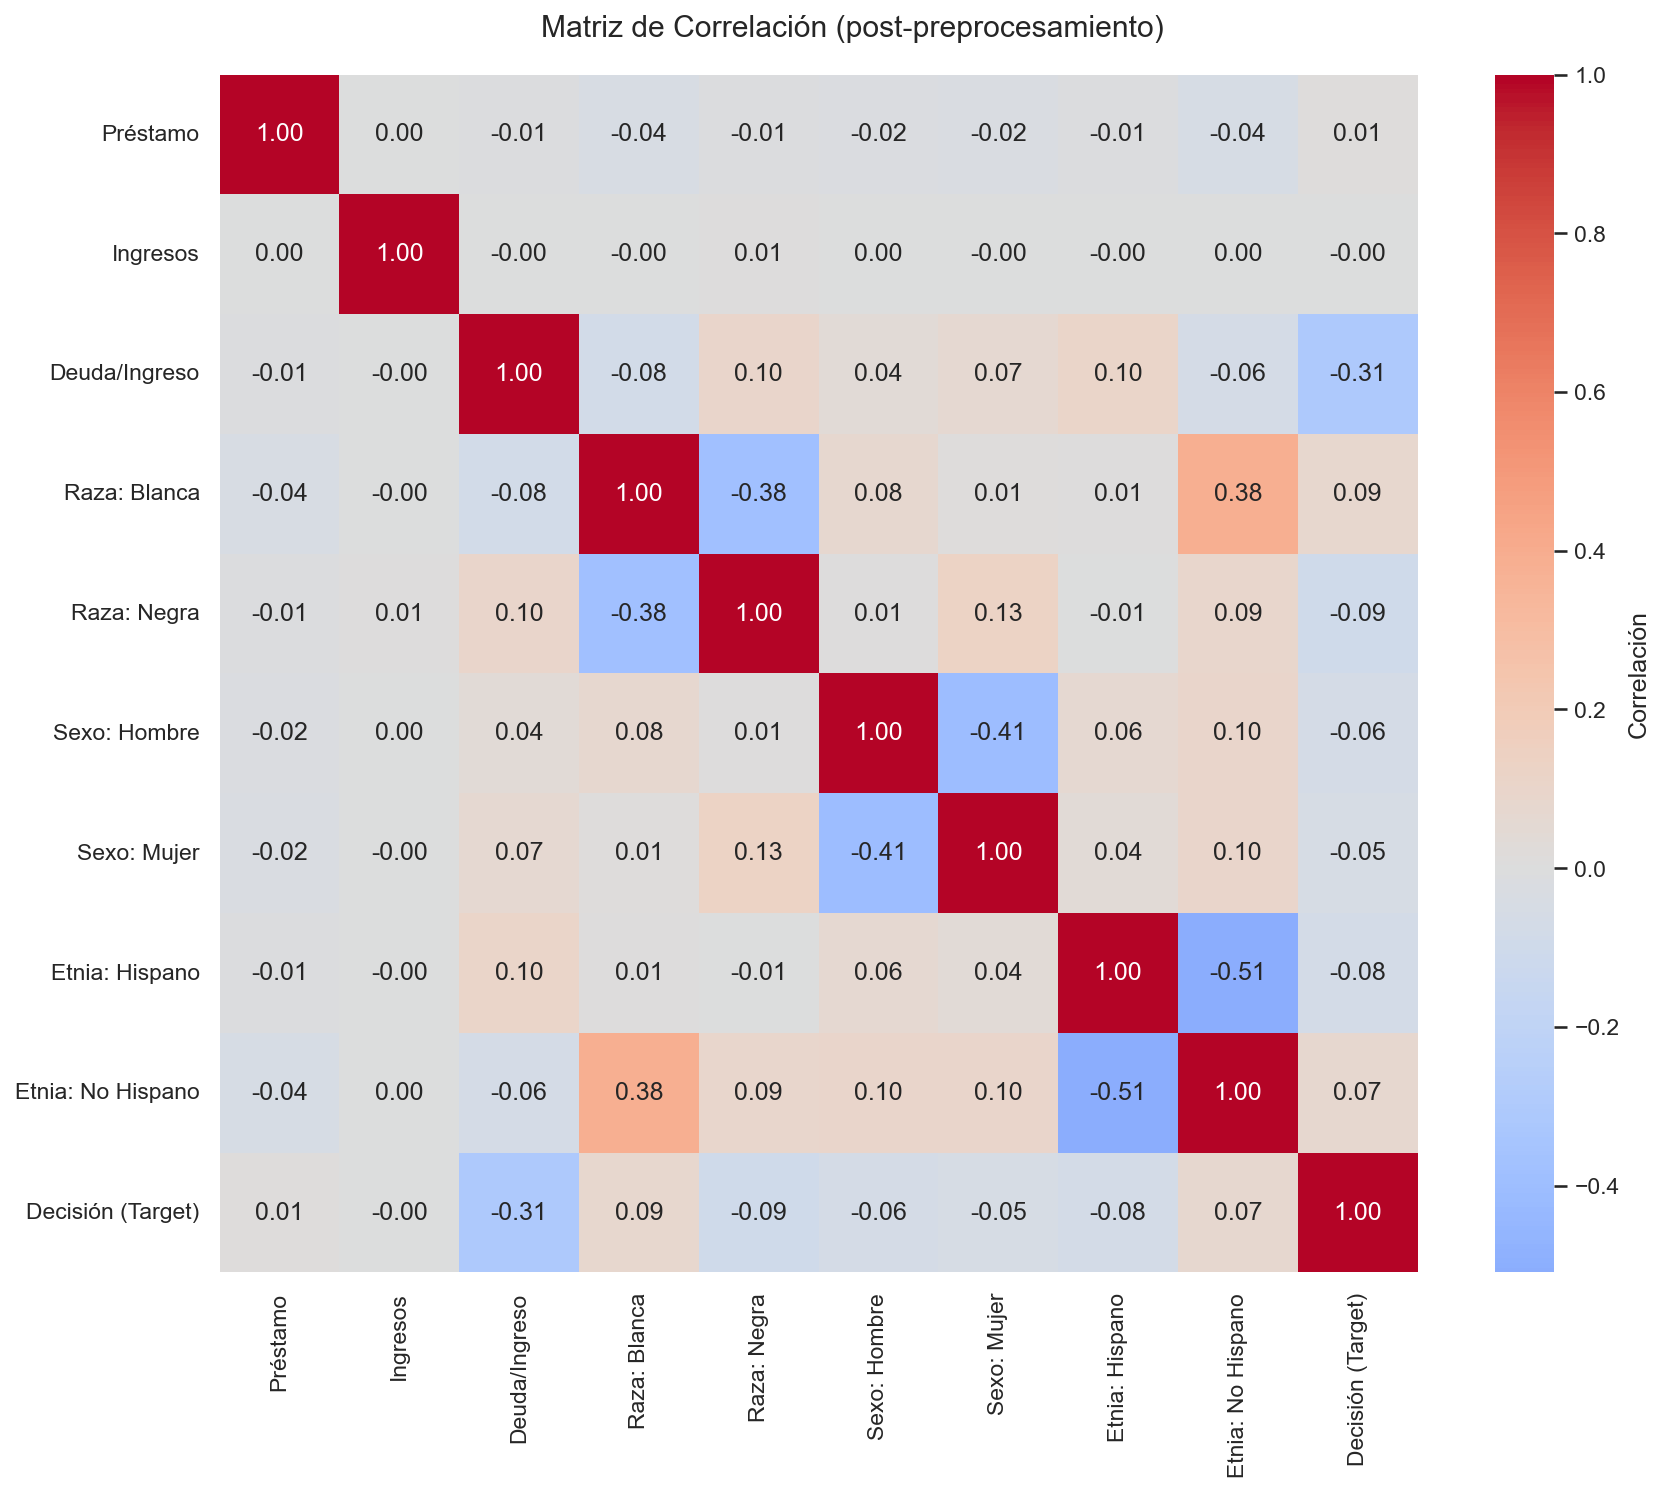

In [40]:
# Selección de columnas equivalentes post-OHE
cols_correlacion_post = [
    'loan_amount', 'income', 'debt_to_income_ratio',
    'derived_race_White', 'derived_race_Black or African American',
    'derived_sex_Male', 'derived_sex_Female',
    'derived_ethnicity_Hispanic or Latino', 'derived_ethnicity_Not Hispanic or Latino',
    'action_taken'
]

# Reconstruimos df completo para poder calcular correlaciones con el target
df_post = X_train.copy()
df_post['action_taken'] = y_train.reset_index(drop=True)
df_post[SENSITIVE_COLS] = groups_train.reset_index(drop=True)

matriz_corr_post = df_post[cols_correlacion_post].corr()

# Traducción de etiquetas
nombres_corr_post = {
    'loan_amount': 'Préstamo',
    'income': 'Ingresos',
    'debt_to_income_ratio': 'Deuda/Ingreso',
    'derived_race_White': 'Raza: Blanca',
    'derived_race_Black or African American': 'Raza: Negra',
    'derived_sex_Male': 'Sexo: Hombre',
    'derived_sex_Female': 'Sexo: Mujer',
    'derived_ethnicity_Hispanic or Latino': 'Etnia: Hispano',
    'derived_ethnicity_Not Hispanic or Latino': 'Etnia: No Hispano',
    'action_taken': 'Decisión (Target)'
}

matriz_corr_post.index   = [nombres_corr_post.get(c, c) for c in matriz_corr_post.index]
matriz_corr_post.columns = [nombres_corr_post.get(c, c) for c in matriz_corr_post.columns]

# Visualización
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(matriz_corr_post, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Correlación'})
fig.suptitle('Matriz de Correlación (post-preprocesamiento)')
plt.tight_layout()
plt.savefig('../outputs/images/2_5_matriz_correlacion_post.png', dpi=300, bbox_inches='tight')
plt.show()

La matriz de correlación post-preprocesamiento confirma que la estructura de los datos se ha preservado correctamente tras la imputación y el escalado. La correlación más destacada con la variable objetivo es la de `debt_to_income_ratio` (-0.31), lo cual tiene una lógica financiera directa: a mayor ratio de deuda sobre ingresos, mayor probabilidad de denegación del préstamo.

Más relevante para el análisis es la presencia de correlaciones entre los atributos sensibles y la decisión del banco: 
* `Raza: Blanca` presenta una correlación positiva (+0.09) con la aprobación, mientras que `Raza: Negra` muestra una correlación negativa (-0.09). 
* La misma tendencia se observa en la etnia, donde `Etnia: No Hispano` correlaciona positivamente (+0.07) con la aprobación frente a `Etnia: Hispano` (-0.08). 

Aunque estas correlaciones son numéricamente bajas, en un *dataset* de esta magnitud son estadísticamente significativas y suponen el primer indicio de los sesgos que se auditarán en los posteriores cuadernos de *Fairness*.

Aunque gran parte de las características presentan una correlación lineal casi nula, su selección final responde estrictamente a la lógica humana y el conocimiento del negocio. Esto evita depender de Pearson, incapaz de captar relaciones complejas, y evita la "dilución" de características previas correlacionadas del *One-Hot Encoding*. Durante el modelado, utilizaremos la interpretabilidad de los **valores SHAP** para contrastar si estas variables, que teóricamente consideramos cruciales para la decisión, coinciden con las que realmente determinan la predicción del algoritmo.

---
### Guardado Final

Una vez completado el preprocesamiento, se construyen los conjuntos finales reincorporando el target (`action_taken`) y las columnas sensibles (`derived_race_*`, `derived_sex_*`, `derived_ethnicity_*`) a las features procesadas. Las columnas sensibles se excluyen del entrenamiento de los modelos pero se conservan en los CSVs para poder reconstruir los grupos de fairness en notebooks posteriores sin necesidad de volver a procesar el dataset desde cero. El resultado son dos archivos, `train.csv` y `test.csv`, con 226.665 y 56.667 filas respectivamente y 81 columnas cada uno.

In [41]:
train_final = X_train.copy()
train_final[TARGET] = y_train.reset_index(drop=True) #  reset index (evita generación de Nans)
train_final[SENSITIVE_COLS] = groups_train.reset_index(drop=True)

test_final = X_test.copy()
test_final[TARGET] = y_test.reset_index(drop=True)
test_final[SENSITIVE_COLS] = groups_test.reset_index(drop=True)

train_final.to_csv('../data/train.csv', index=False)
test_final.to_csv('../data/test.csv', index=False)

print("Guardado:")
print(f"  train.csv → {train_final.shape}")
print(f"  test.csv  → {test_final.shape}")

Guardado:
  train.csv → (226665, 81)
  test.csv  → (56667, 81)
